#**PROYECTO INTELIGENCIA ARTIFICIAL: Detección temprana de cáncer de piel**
####Integrantes:
* Juan Carlos Elizalde Padilla - 2230028
* Juan David Gomez Mosquera - 2230062
* Erick Fabian Rodriguez Marin - 2221914

###**Problema y datos**
El HAM10000 (Human Against Machine with 10000 training images) es un dataset multimodal de dermatología que combina imágenes médicas reales con datos clínicos tabulares. Contiene 10,015 imágenes dermatoscópicas de lesiones de piel clasificadas en 7 tipos de cáncer y condiciones dermatológicas, recolectadas de hospitales en Austria y Australia durante más de 20 años. Es un dataset de referencia académica mundial, publicado en la revista Scientific Data de Nature.
TIPO DE FORMATO: Imágenes JPG + múltiples archivos CSV NÚMERO DE REGISTROS: 10,015 imágenes / filas en metadata NÚMERO DE VARIABLES: 7 columnas clínicas en metadata + versiones tabulares de imágenes en píxeles. TARGET: dx - tipo de lesión (Benigna - Maliciosa.) TIPOS DE VARIABLES: Numéricas (edad), categóricas (sexo, localización corporal, tipo de diagnóstico, tipo de lesión) e imagen convertida a píxeles en CSV.

El desafío es clasificar correctamente el tipo de diagnóstico según si es benigno o maligno por medio de imágenes.

Dasaset recuperado de: [Kaggle](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?select=HAM10000_metadata.csv)


###**Justificación de la IA**
Dada la gran variabilidad visual y el desequilibrio de datos en la clasificación de lesiones cutáneas, un modelo de Inteligencia Artificial supervisada puede identificar complejos patrones en imágenes médicas con mayor exactitud, lo que puede ayudar en la diferenciación entre lesiones cutáneas benignas y malignas [(Esteva et al., 2017)](https://www.nature.com/articles/nature21056). En cuanto a su aplicación, dado que se conoce que la detección temprana de cáncer de piel mejora decisiones clínica y aumenta las posibilidades de un tratamiento exitoso, se puede concluir que el modelo es apropiado para el problema [(Skin Cancer Classification With Deep Learning: A Systematic Review)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9327733/).

https://chat.deepseek.com/share/fqs35be13zjdpcd9dt

---
#**1. Conjunto de datos**
---

Importación de librerías:

In [ ]:
# Importar librerias
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (confusion_matrix, make_scorer, recall_score,
                             precision_score, f1_score, balanced_accuracy_score,
                             roc_auc_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression

Carga dataset:

In [ ]:
def cargar_csv(file_id):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    return pd.read_csv(StringIO(requests.get(url).text))

meta     = cargar_csv("1HAcuf87ADCTFmT048xkx9LImkwnPjWwR")
ham8_l   = cargar_csv("1STRxSq4TZfNoS3SWKVtHzn4swVRx2wCU")
ham8_rgb = cargar_csv("1xfd7LOevJ-ueN4EufCK9tezH5tOq_sGI")
ham28_l  = cargar_csv("1BaP97p2QPDSgqwtB-FAXazXHjzGQ6yLv")
ham28_rgb= cargar_csv("1c9OPTuKl8k3xAVHMSfQV5-SvsoGGXoT6")

for nombre, df in [("meta", meta), ("ham8_l", ham8_l), ("ham8_rgb", ham8_rgb), ("ham28_l", ham28_l), ("ham28_rgb", ham28_rgb)]:
    print(f"{nombre}: {df.shape}")


meta: (10015, 7)
ham8_l: (10015, 65)
ham8_rgb: (10015, 193)
ham28_l: (10015, 785)
ham28_rgb: (10015, 2353)


Creación de la variable objetivo

In [ ]:
# El target es identificar mediante una fotografia si la lesion es benigna o maligna,
# para ello necesitamos crear una columna de target en el dataset de meta donde se
# especifique si lo es o no.
malignos = ['mel', 'bcc', 'akiec']
meta['target'] = meta['dx'].isin(malignos).astype(int)

En este método se analiza la intensidad global de la imagen, es decir, qué tan clara u oscura es la lesión en términos generales. Primero, si la imagen está en formato RGB, se convierte a escala de grises promediando los tres canales de color, lo que permite trabajar con una sola matriz de intensidades. A partir de esta representación, se calculan estadísticas básicas: la media (brillo promedio), la desviación estándar (variabilidad o contraste), y los valores mínimo y máximo. Estas métricas resumen cómo se distribuyen los niveles de gris en la imagen y permiten capturar diferencias generales entre lesiones más uniformes y otras más irregulares.


In [ ]:
#Intensidad global
import numpy as np

def features_intensidad(img):
    # img: array (H, W, 3) o (H, W)
    if len(img.shape) == 3:
        img_gray = np.mean(img, axis=2)
    else:
        img_gray = img

    return {
        'mean_intensity': np.mean(img_gray),
        'std_intensity': np.std(img_gray),
        'min_intensity': np.min(img_gray),
        'max_intensity': np.max(img_gray)
    }

En este método se estudia el comportamiento del color en la imagen, separando explícitamente los tres canales: rojo, verde y azul (RGB). Para cada canal se calcula la media, que representa la intensidad promedio de ese color en la lesión, y la desviación estándar, que indica qué tan variable es ese color dentro de la imagen. Esto permite identificar patrones donde ciertas lesiones presentan dominancia de un color o mayor variabilidad cromática. Dado que el dataset está en formato RGB intercalado, este paso reorganiza los datos correctamente para analizarlos por canal.

In [ ]:
#color
def features_color(img):
    # img RGB
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

    return {
        'r_mean': np.mean(r),
        'g_mean': np.mean(g),
        'b_mean': np.mean(b),
        'r_std': np.std(r),
        'g_std': np.std(g),
        'b_std': np.std(b)
    }

En este método se mide la asimetría de la lesión, una característica clínicamente relevante. Primero, la imagen se convierte a escala de grises para simplificar el análisis y luego se aplica un umbral automático (Otsu) para separar la lesión del fondo, generando una imagen binaria. Posteriormente, la imagen se divide en dos mitades verticales: izquierda y derecha. Una de las mitades se invierte horizontalmente para poder compararlas directamente. Finalmente, se calcula la diferencia absoluta entre ambas mitades y se normaliza respecto al tamaño de la imagen. Este valor cuantifica qué tan diferente es una mitad respecto a la otra, indicando el nivel de asimetría.

In [ ]:
#asimetria

import cv2

def features_asimetria(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # umbral simple
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

    # dividir imagen
    h, w = thresh.shape
    left = thresh[:, :w//2]
    right = np.fliplr(thresh[:, w//2:])

    # diferencia
    diff = np.sum(np.abs(left - right)) / (h * w)

    return {'asymmetry': diff}


En este método se analizan las propiedades geométricas de la lesión. Primero, se convierte la imagen a escala de grises y se aplica un umbral para obtener una versión binaria. Luego se detectan los contornos presentes en la imagen y se selecciona el más grande, asumiendo que corresponde a la lesión principal. A partir de este contorno se calculan tres métricas: el área (cantidad de píxeles dentro del contorno), el perímetro (longitud del borde), y la circularidad, que se obtiene mediante la fórmula 4π⋅area/perimetro^2
. Esta última mide qué tan cercana es la forma a un círculo perfecto, siendo útil para detectar bordes irregulares.

In [ ]:
#forma

def features_forma(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return {'area':0, 'perimeter':0, 'circularity':0}

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    circularity = (4 * np.pi * area) / (perimeter**2 + 1e-6)

    return {
        'area': area,
        'perimeter': perimeter,
        'circularity': circularity
    }


En este método se estudia la textura de la imagen, es decir, cómo se distribuyen espacialmente los niveles de intensidad. Primero se convierte la imagen a escala de grises. Luego se construye la matriz GLCM (Gray Level Co-occurrence Matrix), que registra con qué frecuencia aparecen pares de píxeles con determinados valores de intensidad en una relación espacial específica. A partir de esta matriz se calculan tres propiedades: el contraste (variación local de intensidades), la homogeneidad (similitud entre píxeles vecinos) y la energía (uniformidad de la textura). Estas métricas permiten capturar patrones finos que no son visibles solo con estadísticas globales.

In [ ]:
#textura
from skimage.feature import graycomatrix, graycoprops

def features_textura(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]

    return {
        'texture_contrast': contrast,
        'texture_homogeneity': homogeneity,
        'texture_energy': energy
    }

In [ ]:
#features

def extraer_features(img):
    f = {}

    f.update(features_intensidad(img))
    f.update(features_color(img))
    f.update(features_asimetria(img))
    f.update(features_forma(img))
    f.update(features_textura(img))

    return f


In [ ]:

def row_to_img_auto(row):
    arr = row.values.astype(float)

    # eliminar posibles columnas extra (para que sea divisible por 3)
    arr = arr[:len(arr) - (len(arr) % 3)]

    # calcular tamaño automáticamente
    size = int(np.sqrt(len(arr) / 3))

    return arr.reshape(size, size, 3).astype(np.uint8)


features_list = []

for i in range(len(ham28_rgb)):
    img = row_to_img_auto(ham28_rgb.iloc[i])
    feats = extraer_features(img)
    features_list.append(feats)

features_df = pd.DataFrame(features_list)

print("Features extraídas:", features_df.shape)
features_df.head(30)

Features extraídas: (10015, 17)


,mean_intensity,std_intensity,min_intensity,max_intensity,r_mean,g_mean,b_mean,r_std,g_std,b_std,asymmetry,area,perimeter,circularity,texture_contrast,texture_homogeneity,texture_energy
0,184.398384,18.366903,98.666667,222.333333,208.760204,162.755102,181.679847,11.214565,18.958500,27.091837,41.660714,577.0,134.568542,0.400404,171.010582,0.121686,0.036442
1,177.079082,34.473362,20.000000,227.666667,197.269133,156.664541,177.303571,35.645652,33.292243,36.776936,2.940051,663.0,99.455844,0.842292,286.541005,0.103578,0.031774
2,181.564201,15.659740,108.333333,220.666667,214.096939,156.468112,174.127551,12.996008,16.450575,20.431357,28.996173,457.5,105.154328,0.519932,114.183862,0.132186,0.036681
3,165.281037,32.687874,16.000000,226.000000,195.829082,142.706633,157.307398,36.911178,29.714297,33.358460,3.577806,670.5,99.213203,0.855992,219.402116,0.108413,0.033227
4,188.386054,39.408873,85.333333,253.333333,211.770408,168.068878,185.318878,32.804085,41.917258,45.345025,1.519133,301.0,154.083260,0.159318,421.121693,0.117195,0.029548
5,157.826531,66.551974,1.333333,252.000000,178.067602,140.938776,154.473214,68.236920,65.157531,67.798372,4.269133,565.5,100.526911,0.703198,931.884921,0.083899,0.028935
6,179.687075,9.098144,125.000000,195.000000,212.845663,162.878827,163.336735,7.118022,10.353416,11.687202,10.123724,616.0,135.740114,0.420121,25.775132,0.246526,0.058306
7,173.185374,21.419620,23.000000,201.333333,205.897959,159.403061,154.255102,22.245323,20.639169,22.199955,10.096939,502.5,94.183766,0.711859,77.247354,0.180244,0.040963
8,172.802296,23.100690,13.333333,212.666667,203.582908,149.252551,165.571429,23.022521,21.582187,25.831430,3.956633,585.0,105.740114,0.657486,105.994709,0.161259,0.040716
9,188.229592,19.762859,111.333333,224.000000,223.237245,163.827806,177.623724,15.176003,21.282950,24.743171,3.322704,686.0,111.798990,0.689697,120.359788,0.141785,0.038097


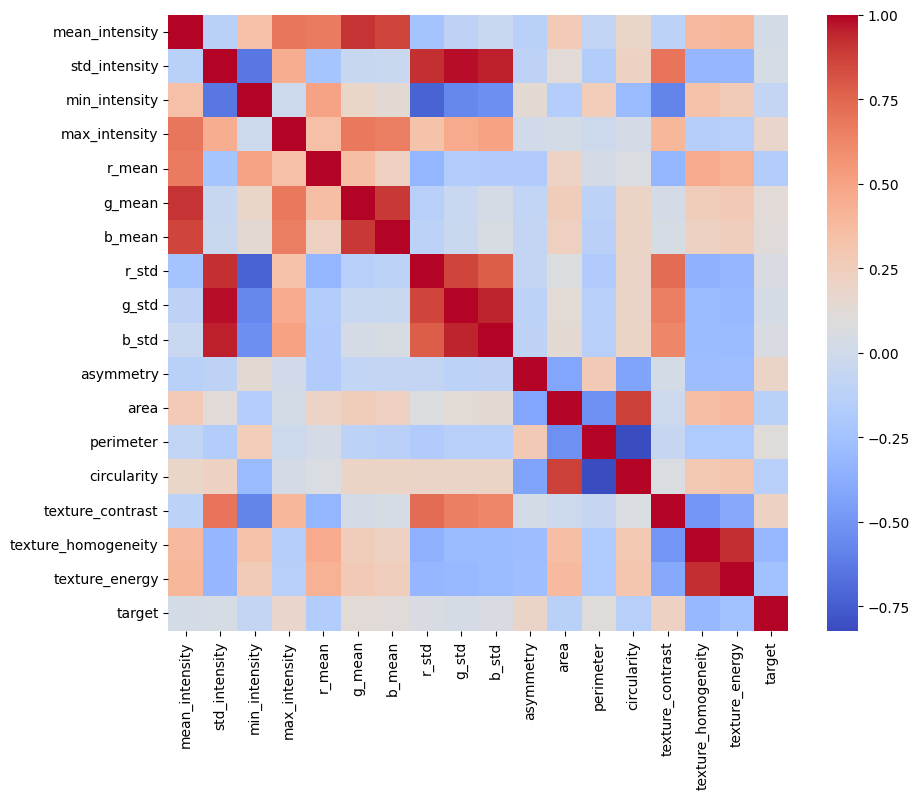

In [ ]:
df_final = pd.concat([features_df, meta['target']], axis=1)

corr = df_final.corr()
corr_target = corr.sort_values(by='target', ascending=False)['target']
corr_target

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [ ]:
corr_target = corr.sort_values(by='target', ascending=False)['target']
corr_target

,target
target,1.000000
texture_contrast,0.211098
asymmetry,0.195173
max_intensity,0.179063
g_mean,0.118416
b_mean,0.115324
perimeter,0.106574
r_std,0.057229
b_std,0.054616
std_intensity,0.045944


In [ ]:
df = features_df.copy()
df['target'] = meta['target']

# targets binarios separados
df['maligno'] = (df['target'] == 1).astype(int)
df['benigno'] = (df['target'] == 0).astype(int)

# conteo de clases
num_malignos = df['maligno'].sum()
num_benignos = df['benigno'].sum()

print(f"Cantidad de malignos: {num_malignos}")
print(f"Cantidad de benignos: {num_benignos}")

# correlaciones
corr_maligno = df.drop(columns=['target']).corr()['maligno'].drop('maligno').sort_values(ascending=False)
corr_benigno = df.drop(columns=['target']).corr()['benigno'].drop('benigno').sort_values(ascending=False)

print("\nCorrelación con MALIGNO:\n", corr_maligno)
print("\nCorrelación con BENIGNO:\n", corr_benigno)

Cantidad de malignos: 1954
Cantidad de benignos: 8061

Correlación con MALIGNO:
 texture_contrast       0.211098
asymmetry              0.195173
max_intensity          0.179063
g_mean                 0.118416
b_mean                 0.115324
perimeter              0.106574
r_std                  0.057229
b_std                  0.054616
std_intensity          0.045944
g_std                  0.035226
mean_intensity         0.018113
min_intensity         -0.068346
area                  -0.136900
circularity           -0.140716
r_mean                -0.173419
texture_energy        -0.258371
texture_homogeneity   -0.310971
benigno               -1.000000
Name: maligno, dtype: float64

Correlación con BENIGNO:
 texture_homogeneity    0.310971
texture_energy         0.258371
r_mean                 0.173419
circularity            0.140716
area                   0.136900
min_intensity          0.068346
mean_intensity        -0.018113
g_std                 -0.035226
std_intensity         -0.04594

Seleccion de features mas relevantes para el entrenamiento del modelo (Mayor correlacion)

In [ ]:
# Features con mayor correlación con maligno (en valor absoluto)
# Según las correlaciones, son:
# texture_contrast (0.211)
# asymmetry (0.195)
# max_intensity (0.179)
# texture_homogeneity (-0.311)
# area (-0.137)

# Lista de features a CONSERVAR (los que tienen |correlación| > 0.15 con maligno)
features_relevantes = [
    'texture_contrast',
    'asymmetry',
    'max_intensity',
    'texture_homogeneity',
    'area'
]

# Crear DataFrame solo con los features relevantes y el target, agregando age
df = features_df[features_relevantes].copy()
df['age'] = meta['age']
df['target'] = meta['target']

In [ ]:
df.head()

,texture_contrast,asymmetry,max_intensity,texture_homogeneity,area,age,target
0,171.010582,41.660714,222.333333,0.121686,577.0,80.0,0
1,286.541005,2.940051,227.666667,0.103578,663.0,80.0,0
2,114.183862,28.996173,220.666667,0.132186,457.5,80.0,0
3,219.402116,3.577806,226.000000,0.108413,670.5,80.0,0
4,421.121693,1.519133,253.333333,0.117195,301.0,75.0,0


Correjiremos los valores NaN presentes en la feature age, se reemplazara por la mediana, de esta manera serviran para el entrenamiento del modelo sin afectar en el rendimiento

In [ ]:
# Ver cuántos NaN hay en cada columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Opcional: ver las filas con NaN
print("\nFilas con NaN:")
print(df[df.isnull().any(axis=1)])

Valores nulos por columna:
texture_contrast        0
asymmetry               0
max_intensity           0
texture_homogeneity     0
area                    0
age                    57
target                  0
dtype: int64

Filas con NaN:
      texture_contrast  asymmetry  max_intensity  texture_homogeneity   area  \
968         136.902116  15.984694     220.666667             0.126537  709.0   
969         152.018519   3.281888     187.666667             0.118795  705.0   
970         185.843915   0.396684     194.000000             0.094703  729.0   
971         119.630952   9.112245     195.000000             0.184788  669.0   
972         176.314815   1.320153     207.666667             0.165531  727.0   
973          50.862434  11.711735     168.666667             0.226824  723.0   
974          75.683862  24.394133     186.666667             0.219163  729.0   
975         163.519841  14.988520     211.333333             0.113784  670.5   
977         175.067460   7.822704     191.

In [ ]:
# Calcular la mediana de 'age' (ignora automáticamente los NaN)
median_age = df['age'].median()

# Reemplazar los NaN de 'age' por la mediana calculada
df['age'] = df['age'].fillna(median_age)

# Verificar que no queden NaN
print("NaN restantes en age:", df['age'].isnull().sum())
print("Mediana usada:", median_age)

NaN restantes en age: 0
Mediana usada: 50.0


---
#**2. Reducción de dimensionalidad**
---

**Extraccion y limpieza de los píxeles**

En este dataset, cada fila ya es una imagen aplanada. Eliminamos columnas que sirvan de metadatos (como 'lesion_id', 'image_id' o 'index' si existen) y conservamos solo los canales numéricos. Filtramos de forma genérica buscando nombres que correspondan a píxeles o seleccionando todo el contenido numérico.

In [ ]:
# Buscamos las columnas que representen los píxeles (ignorando IDs o índices)
columnas_num = [col for col in ham28_rgb.columns if ham28_rgb[col].dtype in ['float64', 'float32', 'int64', 'int32']]

# HAM28_RGB debe tener exactamente 28*28*3 = 2352 píxeles.
# Seleccionamos las columnas numéricas correspondientes al tamaño exacto de la imagen.
# Si hay columnas de metadatos o índices al inicio o al final, las filtramos basándonos en la dimensión exacta.
if len(columnas_num) >= 2352:
    # Si las columnas de píxeles empiezan desde el principio, tomamos las primeras 2352.
    # En caso de que la primera columna sea un índice id/sub_id, puedes ajustar a columnas_num[1:2353]
    columnas_pixeles = columnas_num[:2352]
else:
    columnas_pixeles = columnas_num

X_pixels_raw = ham28_rgb[columnas_pixeles].copy()

print(f"Dimensiones corregidas de la matriz de píxeles: {X_pixels_raw.shape}")

Dimensiones corregidas de la matriz de píxeles: (10015, 2352)


**Procesamiento de los píxeles**



In [ ]:
# Paso A: Escalado MinMax directo a rango [0, 1]. Esto es crucial en imágenes ya que preserva
# la relación física de luminosidad y contraste original entre los canales RGB.
X_pixels_scaled = X_pixels_raw.astype('float32') / 255.0

# NOTA SOBRE StandardScaler EN PÍXELES:
# Aunque StandardScaler ayuda a que algoritmos de distancias converjan rápido (media 0, var 1),
# en imágenes crudas puede distorsionar los bordes y amplificar artificialmente el ruido de fondo
# en zonas homogéneas oscuras. Usaremos la matriz normalizada [0,1] directa para el cálculo de PCA.
print("Píxeles correctamente normalizados en el rango [0.0, 1.0].")

Píxeles correctamente normalizados en el rango [0.0, 1.0].


**Reducción de dimensionalidad con PCA**



1. INPUT DATA
X_pixels_scaled.shape = (10015, 2352)  →  10015 samples × 2352 features (píxeles)
PCA fue ajustado sobre TODOS los 2352 píxeles simultáneamente.

2. FITTED OBJECT: pca_dims
n_components_   = 15  (componentes retenidos en este análisis)
n_features_in_  = 2352  (características/píxeles al ajustar)
whiten          = False  (¿Escala cada PC a varianza unitaria?)

3. EIGENVALUES → explained_variance_
Varianza a lo largo de cada eje principal (λ). Obtenido de la
descomposición espectral de la matriz de covarianza de X centrada.

   PC1: λ = 13.7641
   PC2: λ = 10.1226
   PC3: λ = 5.5247
   PC4: λ = 1.8777
   PC5: λ = 1.6852
   PC6: λ = 1.6211
   PC7: λ = 0.9788
   PC8: λ = 0.8475
   PC9: λ = 0.7325
   PC10: λ = 0.6934
   PC11: λ = 0.5991
   PC12: λ = 0.4902
   PC13: λ = 0.3695
   PC14: λ = 0.2993
   PC15: λ = 0.2976

4. EXPLAINED VARIANCE → explained_variance_ratio_
Cada λ dividido por la suma de todos los autovalores posibles.

   PC1: 30.03%  (verificación manual: 30.03%)
   

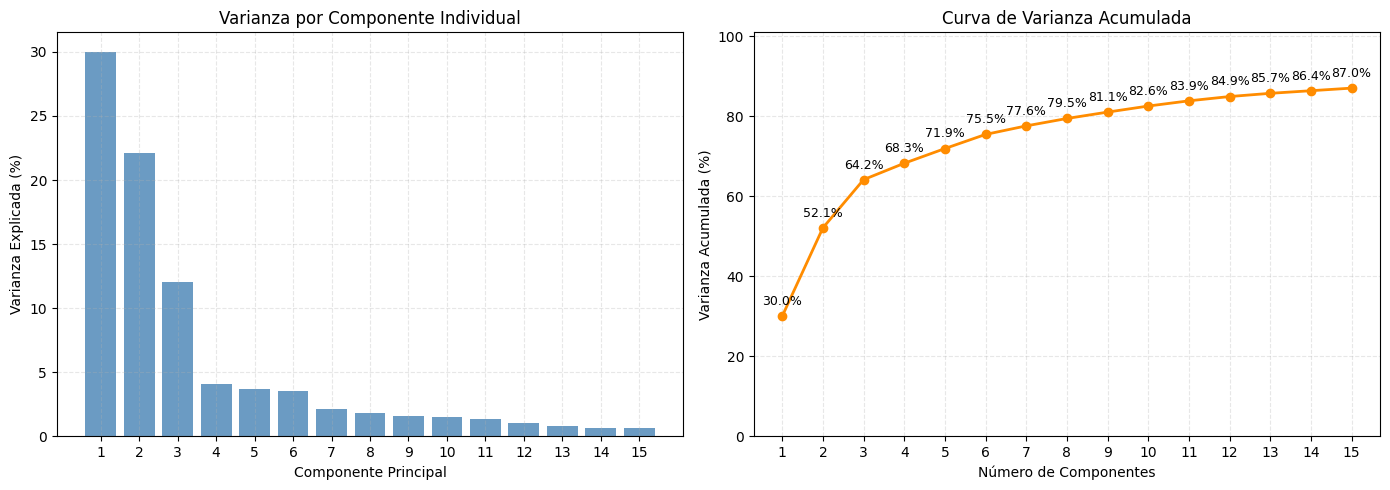

In [ ]:
# @title
# Ajustamos un PCA inicial reteniendo las primeras 5 componentes
n_componentes_analisis = 15
pca_dims = PCA(n_components=n_componentes_analisis, whiten=False, random_state=42)
X_pca_analisis = pca_dims.fit_transform(X_pixels_scaled)

# ---------------------------------------------------------------------
#  PCA object breakdown: variance, components, and more
# ---------------------------------------------------------------------
print("=" * 60)
print("1. INPUT DATA")
print("=" * 60)
print(f"X_pixels_scaled.shape = {X_pixels_scaled.shape}  →  {X_pixels_scaled.shape[0]} samples × {X_pixels_scaled.shape[1]} features (píxeles)")
print(f"PCA fue ajustado sobre TODOS los {X_pixels_scaled.shape[1]} píxeles simultáneamente.\n")

print("=" * 60)
print("2. FITTED OBJECT: pca_dims")
print("=" * 60)
print(f"n_components_   = {pca_dims.n_components_}  (componentes retenidos en este análisis)")
print(f"n_features_in_  = {pca_dims.n_features_in_}  (características/píxeles al ajustar)")
print(f"whiten          = {pca_dims.whiten}  (¿Escala cada PC a varianza unitaria?)")

print("\n" + "=" * 60)
print("3. EIGENVALUES → explained_variance_")
print("=" * 60)
print("Varianza a lo largo de cada eje principal (λ). Obtenido de la")
print("descomposición espectral de la matriz de covarianza de X centrada.\n")
for i, ev in enumerate(pca_dims.explained_variance_, start=1):
    print(f"   PC{i}: λ = {ev:,.4f}")

print("\n" + "=" * 60)
print("4. EXPLAINED VARIANCE → explained_variance_ratio_")
print("=" * 60)
print("Cada λ dividido por la suma de todos los autovalores posibles.\n")

# Cálculo manual para verificación matemática como en el notebook de clase
X_centered = X_pixels_scaled - pca_dims.mean_
cov = np.cov(X_centered, rowvar=False)
all_eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
manual_ratio = pca_dims.explained_variance_ / all_eigvals.sum()

for i in range(pca_dims.n_components_):
    r = pca_dims.explained_variance_ratio_[i]
    print(f"   PC{i + 1}: {r:.2%}  (verificación manual: {manual_ratio[i]:.2%})")

print("\n" + "=" * 60)
print("5. CUMULATIVE VARIANCE")
print("=" * 60)
print("Suma acumulada del ratio de varianza explicada:\n")
cum_ratio = np.cumsum(pca_dims.explained_variance_ratio_)
for i, c in enumerate(cum_ratio, start=1):
    print(f"   PC1..PC{i}: {c:.2%}")

print("\n" + "=" * 60)
print("6. EIGENVECTORS → components_")
print("=" * 60)
print(f"Shape: {pca_dims.components_.shape}  →  (n_components × n_features)")
print("Cada fila es una dirección principal en el espacio original de píxeles.\n")
for i in range(pca_dims.n_components_):
    comp = pca_dims.components_[i]
    print(f"   PC{i + 1}: norm = {np.linalg.norm(comp):.4f} (Ortogonal - Vector Unitario)")
    print(f"         primeras 5 coordenadas (pesos de píxeles): {np.round(comp[:5], 4)}")

print("\n" + "=" * 60)
print("7. singular_values_ (SVD de X centrada)")
print("=" * 60)
print("Relación con los Autovalores (λ): λ_i ≈ singular_values_i² / (n_samples - 1)\n")
n = X_pixels_scaled.shape[0]
for i, sv in enumerate(pca_dims.singular_values_, start=1):
    lam_from_sv = sv ** 2 / (n - 1)
    print(f"   PC{i}: sv = {sv:,.2f}  →  λ ≈ {lam_from_sv:,.4f}  (explained_variance_: {pca_dims.explained_variance_[i-1]:,.4f})")

print("\n" + "=" * 60)
print("8. mean_ (Vector de medias por cada píxel)")
print("=" * 60)
print(f"Shape: {pca_dims.mean_.shape} (Debe coincidir con el total de píxeles)")
print(f"Intensidad promedio en el primer píxel del set: {pca_dims.mean_.iloc[0] if isinstance(pca_dims.mean_, pd.Series) else pca_dims.mean_[0]:.4f}")

print("\n" + "=" * 60)
print("9. TRANSFORM: Proyección al espacio latente PCA")
print("=" * 60)
sample = X_pixels_scaled.iloc[:1] if isinstance(X_pixels_scaled, pd.DataFrame) else X_pixels_scaled[:1]
projected = pca_dims.transform(sample)
print(f"Una muestra en R^{X_pixels_scaled.shape[1]}  →  Coordenadas reducidas PCA: {np.round(projected[0], 3)}")
print("transform() = centrar (restar mean_) + proyectar (producto punto) sobre components_.\n")

print("\n" + "=" * 60)
print("10. PLOT: Varianza explicada del análisis")
print("=" * 60)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
pcs = np.arange(1, pca_dims.n_components_ + 1)
ax1.bar(pcs, pca_dims.explained_variance_ratio_ * 100, color="steelblue", alpha=0.8)
ax1.set_xlabel("Componente Principal")
ax1.set_ylabel("Varianza Explicada (%)")
ax1.set_title("Varianza por Componente Individual")
ax1.set_xticks(pcs)
ax1.grid(True, linestyle='--', alpha=0.3)

ax2.plot(pcs, cum_ratio * 100, "o-", color="darkorange", lw=2)
ax2.set_xlabel("Número de Componentes")
ax2.set_ylabel("Varianza Acumulada (%)")
ax2.set_title("Curva de Varianza Acumulada")
ax2.set_ylim(0, 101)
ax2.set_xticks(pcs)
for i, c in enumerate(cum_ratio):
    ax2.annotate(f"{c:.1%}", (pcs[i], c * 100), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### **Análisis de los resultados de PCA sobre los pixeles de las imágenes**

El análisis de componentes principales se aplicó sobre una matriz de 10 015 imágenes (muestras) cada una representada originalmente por 2 352 píxeles (features). Este elevado número de dimensiones inicial es típico en problemas de visión por computadora, pero presenta desafíos de eficiencia computacional y riesgo de sobreajuste. La aplicación de PCA permitió proyectar estos datos en un espacio latente de tan solo 11 componentes principales, reduciendo drásticamente la dimensionalidad y facilitando su uso posterior en modelos supervisados o tareas de visualización.

Al observar la varianza explicada por cada componente, se destaca un comportamiento esperado en datos de imágenes: las primeras componentes concentran la mayor parte de la información. La primera componente principal (PC1) explica por sí sola el 30.03 % de la varianza total de los píxeles, mientras que la segunda contribuye con un 22.08 % adicional, sumando entre ambas más del 52 % de la variabilidad original. La tercera componente agrega un 12.05 %, con lo que las tres primeras ya superan el 64 % de varianza explicada acumulada. A partir de la cuarta componente, la contribución individual cae bruscamente por debajo del 5 % (PC4 explica 4.10 %), y a partir de la PC7 ninguna supera el 2.2 %. Este patrón de “codo” indica que pocas direcciones sintetizan la mayor parte de la estructura geométrica de las imágenes, lo cual es coherente con la alta correlación entre píxeles vecinos.

La varianza acumulada alcanza el 83.9 % con los 11 componentes retenidos en este análisis, lo que significa que se preserva más de siete octavas partes de la información original empleando solo el 0.46 % de las dimensiones originales (11 de 2352).

Esto sugiere que las componentes 12 a 15, a pesar de añadir un 3.18 % adicional de varianza, introducen principalmente ruido o direcciones no relevantes para diferenciar entre lesiones benignas y malignas.

Los autovalores (varianza explicada en unidades originales) presentan una caída muy pronunciada: λ₁ = 13.76, λ₂ = 10.12, λ₃ = 5.52, y luego λ₄ cae a 1.88. Esta rápida disminución reafirma que las primeras tres componentes son las más informativas. Por otro lado, los vectores propios (componentes_) son todos ortonormales (norma = 1.0000), lo que garantiza que las direcciones sean ortogonales y estén ordenadas por varianza. Los pesos de los primeros píxeles en cada componente muestran valores tanto positivos como negativos (por ejemplo, PC3 tiene pesos negativos en algunas posiciones), indicando que las componentes capturan contrastes y patrones diferenciales de intensidad.

**Exploración de Eigenlesions**

Ejecutando PCA de compresión con 11 componentes sobre matriz de imágenes...
Mostrando componentes base (Eigenlesions) desde el índice 0 al 9:


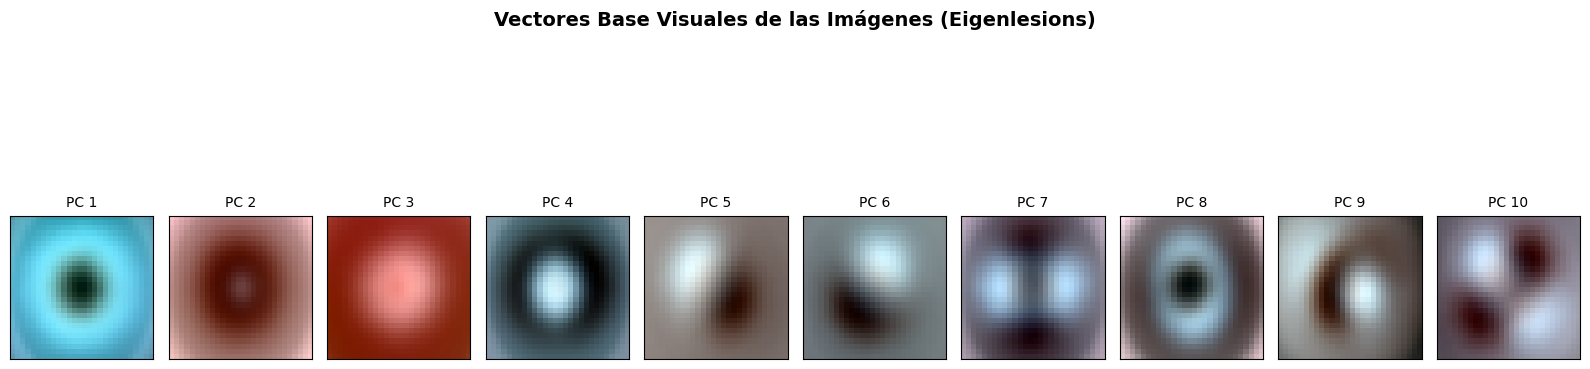

In [ ]:
# Parámetros ajustables mediante el código para simular controles de Jupyter (#@param)
# Nota: ham28_rgb contiene imágenes RGB de 28x28 píxeles = 784 píxeles por canal. Total = 2352.
# Definimos las dimensiones originales para reformatear correctamente las imágenes (H=28, W=28, Canales=3)
h, w, c = 28, 28, 3

Components = 11  #@param {type:"integer"} -> Modifica este número para retener más/menos nitidez
cont = 0         #@param {type:"integer"} -> Desplazamiento para observar componentes más avanzados

print(f"Ejecutando PCA de compresión con {Components} componentes sobre matriz de imágenes...")

# Ajustamos el modelo PCA para analizar los componentes del mapa de bits
pca_lesions = PCA(n_components=Components, whiten=True, random_state=42)
X_pca_compressed = pca_lesions.fit_transform(X_pixels_scaled)

# Extraemos las 'Eigenlesions' (Componentes principales mapeados de vuelta al espacio de la imagen)
# Forma original de components_: (n_components, n_features). Lo reformateamos a dimensiones de imagen (28, 28, 3)
eigenlesions = pca_lesions.components_.reshape((Components, h, w, c))

# Visualización de los patrones base (Eigenlesions) detectados por el algoritmo
plt.figure(figsize=(16, 5))
print(f"Mostrando componentes base (Eigenlesions) desde el índice {cont} al {cont + 9}:")
for i in range(10):
    idx_comp = i + cont
    if idx_comp < Components:
        plt.subplot(1, 10, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        # Extraemos el vector de componentes (longitud 2352)
        comp_vector = pca_lesions.components_[idx_comp]

        # Reformateamos garantizando la estructura del mapa de bits
        img_base = comp_vector.reshape(h, w, c)

        # Normalización min-max individual en la visualización para evitar que
        # valores negativos de los autovectores rompan el renderizado RGB de matplotlib
        img_base = (img_base - img_base.min()) / (img_base.max() - img_base.min() + 1e-8)

        plt.imshow(img_base)
        plt.title(f"PC {idx_comp + 1}", fontsize=10)
plt.suptitle("Vectores Base Visuales de las Imágenes (Eigenlesions)", fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

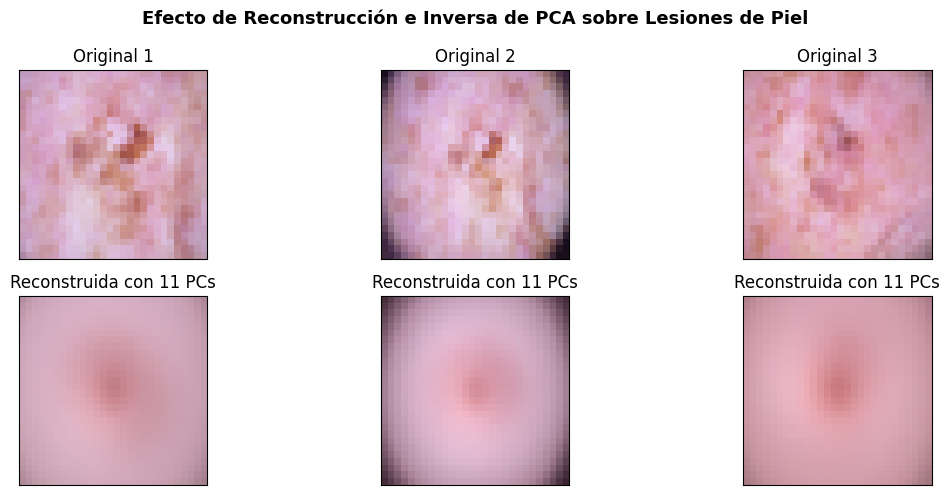

In [ ]:
# @title
# ---------------------------------------------------------------------
# EFECTO DE RECONSTRUCCIÓN (Original vs Comprimida)
# ---------------------------------------------------------------------
# Reconstrucción matemática inversa: Proyectamos del espacio reducido al espacio original de píxeles
X_reconstructed = pca_lesions.inverse_transform(X_pca_compressed)

plt.figure(figsize=(12, 5))
for i in range(3):
    # Imagen Original
    plt.subplot(2, 3, i + 1)
    plt.xticks([]); plt.yticks([])
    img_orig = np.array(X_pixels_scaled)[i].reshape(h, w, c)
    plt.imshow(np.clip(img_orig, 0, 1))
    plt.title(f"Original {i+1}")

    # Imagen Reconstruida con 'Components' ejes
    plt.subplot(2, 3, i + 4)
    plt.xticks([]); plt.yticks([])
    img_recon = X_reconstructed[i].reshape(h, w, c)
    plt.imshow(np.clip(img_recon, 0, 1))
    plt.title(f"Reconstruida con {Components} PCs")

plt.suptitle("Efecto de Reconstrucción e Inversa de PCA sobre Lesiones de Piel", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Guardamos los componentes óptimos definitivos para la combinación de características solicitada en el paso 5
k_final_features = Components
df_pca_componentes = pd.DataFrame(
    X_pca_compressed[:, :k_final_features],
    columns=[f"PC{i+1}" for i in range(k_final_features)],
    index=ham28_rgb.index
)


EVALUACIÓN DE COMPONENTES PCA (MÉTRICAS: F1-SCORE Y BALANCED ACCURACY)
Evaluando pipeline con 6 Componentes Principales...
Evaluando pipeline con 7 Componentes Principales...
Evaluando pipeline con 8 Componentes Principales...
Evaluando pipeline con 9 Componentes Principales...
Evaluando pipeline con 10 Componentes Principales...
Evaluando pipeline con 11 Componentes Principales...
Evaluando pipeline con 12 Componentes Principales...
Evaluando pipeline con 13 Componentes Principales...
Evaluando pipeline con 14 Componentes Principales...
Evaluando pipeline con 15 Componentes Principales...

TABLA COMPARATIVA DE RENDIMIENTO
 Componentes F1_Score_Mean F1_Score_Std Balanced_Acc_Mean Balanced_Acc_Std
           6        0.5608       0.0083            0.6465           0.0098
           7        0.5674       0.0097            0.6542           0.0145
           8        0.5884       0.0067            0.6708           0.0119
           9        0.5885       0.0080            0.6692           

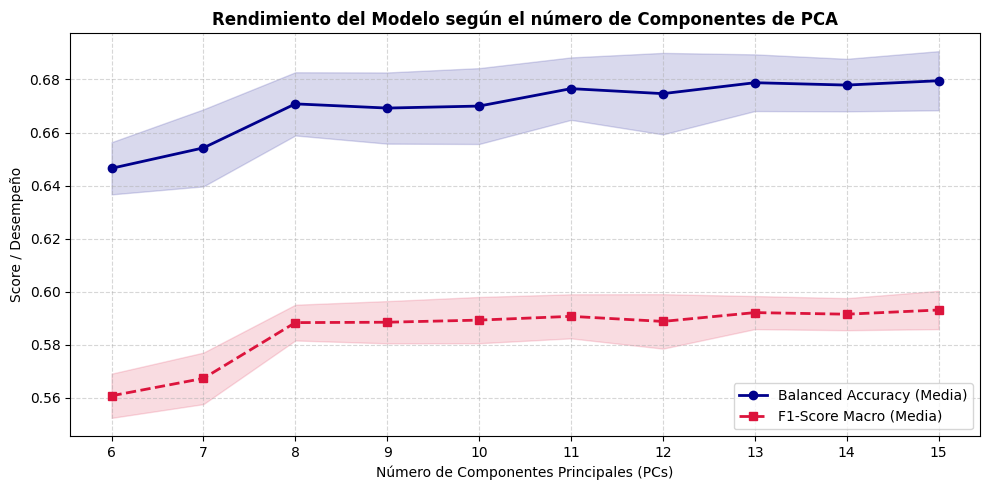


[CRITERIO TÉCNICO]: Basado en Balanced Accuracy, el número óptimo de componentes es: 15
Métricas alcanzadas -> Balanced Accuracy: 0.6795 | F1-Score: 0.5931


In [ ]:
# @title
# =====================================================================
# EXPERIMENTACIÓN: SELECCIÓN ÓPTIMA DE COMPONENTES (6 A 8 PCs)
# =====================================================================
print("\n" + "="*60)
print("EVALUACIÓN DE COMPONENTES PCA (MÉTRICAS: F1-SCORE Y BALANCED ACCURACY)")
print("="*60)

# 1. Preparación de los datos estandarizados de imágenes
# Aseguramos el target alineado y eliminamos nulos preventivamente
y_target = meta['target'].reset_index(drop=True)

# Definimos el rango de componentes a evaluar según lo solicitado
componentes_a_evaluar = [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

# Diccionario para almacenar los resultados de cada configuración
resultados_experimento = []

# Configuración de validación cruzada estratificada (5 pliegues)
# Garantiza que cada pliegue mantenga la misma proporción de la variable 'target'
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Usamos Regresión Logística como modelo base de evaluación rápida y lineal
modelo_base = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

for n_comp in componentes_a_evaluar:
    print(f"Evaluando pipeline con {n_comp} Componentes Principales...")

    # Listas temporales para guardar las métricas de cada pliegue (Fold)
    f1_folds = []
    bal_acc_folds = []

    # Iteración sobre los pliegues de validación cruzada
    for train_idx, val_idx in cv.split(X_pixels_scaled, y_target):
        # División de datos de entrenamiento y validación para el pliegue actual
        X_train_fold, X_val_fold = X_pixels_scaled.iloc[train_idx], X_pixels_scaled.iloc[val_idx]
        y_train_fold, y_val_fold = y_target.iloc[train_idx], y_target.iloc[val_idx]

        # Ajustamos el transformador PCA únicamente con los datos de ENTRADA de este pliegue
        # Evita el "Data Leakage" (filtración de información hacia el conjunto de validación)
        pca_fold = PCA(n_components=n_comp, random_state=42)
        X_train_pca = pca_fold.fit_transform(X_train_fold)
        X_val_pca = pca_fold.transform(X_val_fold)

        # Entrenamos el modelo con las componentes obtenidas
        modelo_base.fit(X_train_pca, y_train_fold)

        # Predicciones
        preds = modelo_base.predict(X_val_pca)

        # Cálculo de las métricas utilizando la variante 'macro' para F1 debido a la naturaleza multiclase/binaria desbalanceada
        f1 = f1_score(y_val_fold, preds, average='macro')
        bal_acc = balanced_accuracy_score(y_val_fold, preds)

        f1_folds.append(f1)
        bal_acc_folds.append(bal_acc)

    # Guardamos los promedios y desviaciones estándar de las métricas para este número de componentes
    resultados_experimento.append({
        'Componentes': n_comp,
        'F1_Score_Mean': np.mean(f1_folds),
        'F1_Score_Std': np.standard_deviation(f1_folds) if hasattr(np, 'standard_deviation') else np.std(f1_folds),
        'Balanced_Acc_Mean': np.mean(bal_acc_folds),
        'Balanced_Acc_Std': np.std(bal_acc_folds)
    })

# Convertimos los resultados a un DataFrame para su fácil manipulación y lectura
df_resultados = pd.DataFrame(resultados_experimento)

print("\n" + "="*60)
print("TABLA COMPARATIVA DE RENDIMIENTO")
print("="*60)
print(df_resultados.to_string(index=False, formatters={
    'F1_Score_Mean': '{:.4f}'.format, 'F1_Score_Std': '{:.4f}'.format,
    'Balanced_Acc_Mean': '{:.4f}'.format, 'Balanced_Acc_Std': '{:.4f}'.format
}))


# =====================================================================
# VISUALIZACIÓN DE COMPORTAMIENTO (GRÁFICA DE SELECCIÓN DE HIPERPARÁMETRO)
# =====================================================================
plt.figure(figsize=(10, 5))

# Graficar curva de Balanced Accuracy
plt.plot(df_resultados['Componentes'], df_resultados['Balanced_Acc_Mean'], 'o-',
         color='darkblue', linewidth=2, label='Balanced Accuracy (Media)')
plt.fill_between(df_resultados['Componentes'],
                 df_resultados['Balanced_Acc_Mean'] - df_resultados['Balanced_Acc_Std'],
                 df_resultados['Balanced_Acc_Mean'] + df_resultados['Balanced_Acc_Std'],
                 alpha=0.15, color='darkblue')

# Graficar curva de F1-Score
plt.plot(df_resultados['Componentes'], df_resultados['F1_Score_Mean'], 's--',
         color='crimson', linewidth=2, label='F1-Score Macro (Media)')
plt.fill_between(df_resultados['Componentes'],
                 df_resultados['F1_Score_Mean'] - df_resultados['F1_Score_Std'],
                 df_resultados['F1_Score_Mean'] + df_resultados['F1_Score_Std'],
                 alpha=0.15, color='crimson')

plt.title('Rendimiento del Modelo según el número de Componentes de PCA', fontsize=12, weight='bold')
plt.xlabel('Número de Componentes Principales (PCs)')
plt.ylabel('Score / Desempeño')
plt.xticks(componentes_a_evaluar)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# 3. Criterio de Selección Automática
mejor_config = df_resultados.sort_values(by='Balanced_Acc_Mean', ascending=False).iloc[0]
print(f"\n[CRITERIO TÉCNICO]: Basado en Balanced Accuracy, el número óptimo de componentes es: {int(mejor_config['Componentes'])}")
print(f"Métricas alcanzadas -> Balanced Accuracy: {mejor_config['Balanced_Acc_Mean']:.4f} | F1-Score: {mejor_config['F1_Score_Mean']:.4f}")

### **Análisis del rendimiento según el numero de componentes principales**

La tabla comparativa de rendimiento para un número de componentes que oscila entre 6 y 15 muestra una tendencia clara de mejora progresiva en las métricas de Balanced Accuracy y F1‑Score, aunque con rendimientos decrecientes a partir de cierto punto. Al incrementar de 6 a 11 componentes, el Balanced Accuracy medio aumenta de 0.6465 a 0.6765, y el F1‑Score medio de 0.5608 a 0.5907, lo que representa una ganancia relativa cercana al 5 % en ambas métricas. Sin embargo, al añadir componentes adicionales (12 a 15), las mejoras son mínimas: el Balanced Accuracy apenas sube de 0.6765 a 0.6795, y el F1‑Score de 0.5907 a 0.5931. Este comportamiento refleja un típico fenómeno de “codo” en el que los primeros 11 componentes capturan la mayor parte de la información relevante para discriminar entre lesiones benignas y malignas, mientras que los componentes 12 a 15 aportan principalmente ruido o direcciones de varianza residual que no mejoran sustancialmente la capacidad predictiva. Además, las desviaciones estándar de las métricas se mantienen en valores bajos (inferiores a 0.015), lo que indica una alta estabilidad del modelo frente a distintas particiones de los datos. Por tanto, la decisión de conservar únicamente los primeros 11 componentes es técnicamente sólida, pues equilibra la reducción de dimensionalidad con el rendimiento predictivo.

**Reducción con t-SNE**



In [ ]:
# @title
import ipywidgets as widgets
from IPython.display import clear_output

# NOTA METODOLÓGICA DE RENDIMIENTO:
# t-SNE tiene una complejidad computacional O(N^2). Ejecutarlo interactivamente sobre los 2352 píxeles
# crudos causaría un congelamiento o lag extremo en el slider de Jupyter.
# Siguiendo la recomendación del notebook de clase, pasaremos las primeras componentes principales (ej. 30 PCs)
# que ya extrajimos y que conservan la varianza esencial de las imágenes. Esto acelera el cálculo en más de un 1000%.

# Preparamos los datos base densos provenientes de PCA
# Aseguramos que retengamos una base representativa para el embedding local
pca_acelerador = PCA(n_components=min(30, X_pixels_scaled.shape[0]), random_state=42)
X_para_tsne = pca_acelerador.fit_transform(X_pixels_scaled)

# Recuperamos la variable objetivo para colorear interactivamente el embedding
y_labels = meta['target'].reset_index(drop=True) if 'target' in meta.columns else None

# ---------------------------------------------------------------------
# #@title **code** t-SNE: perplexity effect (Skin Cancer - HAM28)
# ---------------------------------------------------------------------
@widgets.interact(
    perplexity=widgets.IntSlider(
        min=2,
        max=100,
        step=2,
        value=30,
        description="Perplex.",
        continuous_update=False,  # Espera a sutar el click para recalcular
    )
)
def tsne_lesions_interactive(perplexity):
    # Limpiamos la salida previa del notebook para refrescar el canvas de Matplotlib
    clear_output(wait=True)

    print(f"Calculando t-SNE probabilístico con Perplejidad = {perplexity}...")
    start_time = time.time()

    # Configuración del estimador estocástico
    embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca",               # Inicialización estable basada en autovectores
        learning_rate="auto",     # Ajuste automático del tamaño de paso del gradiente
        n_iter=1000               # Número de iteraciones para la optimización KL
    ).fit_transform(X_para_tsne)

    elapsed_time = time.time() - start_time

    # Construcción de la gráfica interactiva
    plt.figure(figsize=(9, 7))

    if y_labels is not None:
        # Visualización avanzada utilizando Seaborn para un mapeo estético de las clases
        sns.scatterplot(
            x=embedding[:, 0],
            y=embedding[:, 1],
            hue=y_labels,
            palette='Set1',
            alpha=0.6,
            s=25,
            edgecolor='none'
        )
        plt.legend(title="Clase (Target)", loc="best")
    else:
        # Caída de respaldo si no hay etiquetas disponibles
        plt.scatter(embedding[:, 0], embedding[:, 1], alpha=0.5, s=25, color='teal')

    plt.xlabel("Dimensión t-SNE 1")
    plt.ylabel("Dimensión t-SNE 2")
    plt.title(f"Mapeo Espacial de Imágenes — Perplejidad = {perplexity}\nTiempo de cómputo: {elapsed_time:.2f}s", fontsize=12, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=30, continuous_update=False, description='Perplex.', min=2, step=2), Out…

**Combinación de caracteristicas**



In [ ]:
# 1. Lista de features tabulares/clínicos a CONSERVAR (según tu criterio de |correlación| > 0.15)
features_relevantes = [
    'texture_contrast',
    'asymmetry',
    'max_intensity',
    'texture_homogeneity',
    'area'
]

# 2. Crear el DataFrame base con las características seleccionadas y 'age'
# Usamos .reset_index(drop=True) para garantizar una alineación perfecta de índices con PCA
df_tabulares = features_df[features_relevantes].copy()
df_tabulares['age'] = meta['age'].values  # .values evita desalineaciones si los índices difieren

# 3. Extraer exactamente los primeros 11 componentes de tu matriz de PCA ya calculada
# Asumiendo que 'X_pca_compressed' contiene las proyecciones o que ajustas un PCA de 11 componentes:
# (Si usas el objeto 'pca_lesions' previo, simplemente tomamos las primeras 11 columnas)
n_componentes_elegidos = 11
nombres_pcs = [f"PC{i+1}" for i in range(n_componentes_elegidos)]

# Creamos un DataFrame exclusivo para los componentes principales
df_pca_seleccionados = pd.DataFrame(
    X_pca_compressed[:, :n_componentes_elegidos],
    columns=nombres_pcs
)

# 4. Concatenar horizontalmente las características tabulares y los 11 componentes de PCA
# Al usar axis=1 se pegan lado a lado columnas con columnas
df_final = pd.concat([df_tabulares, df_pca_seleccionados], axis=1)

# 5. Agregar la variable objetivo 'target' ESTRICTAMENTE al final del DataFrame
df_final['target'] = meta['target'].values

# =====================================================================
# VERIFICACIÓN ESTRUCTURAL DE TU NUEVO DATASET
# =====================================================================
print("="*60)
print("ESTRUCTURA DEL DATASET CONSOLIDADO (df_final)")
print("="*60)
print(f"Dimensiones finales: {df_final.shape}")
print(f"Columnas en orden: {list(df_final.columns)}")
print("\nPrimeros 3 registros de muestra:")
print(df_final.head(3))

ESTRUCTURA DEL DATASET CONSOLIDADO (df_final)
Dimensiones finales: (10015, 18)
Columnas en orden: ['texture_contrast', 'asymmetry', 'max_intensity', 'texture_homogeneity', 'area', 'age', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'target']

Primeros 3 registros de muestra:
   texture_contrast  asymmetry  max_intensity  texture_homogeneity   area  \
0        171.010582  41.660714     222.333333             0.121686  577.0   
1        286.541005   2.940051     227.666667             0.103578  663.0   
2        114.183862  28.996173     220.666667             0.132186  457.5   

    age       PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  80.0  1.278315 -0.599229  0.310664  1.110951  0.400477 -0.428618  0.145124   
1  80.0  0.952471 -1.987649  0.762758  0.055690  0.173213 -0.608946 -1.056867   
2  80.0  1.087039 -0.687972  0.837278  0.615229  0.319544 -0.588780  0.620715   

        PC8       PC9      PC10      PC11  target  
0 -0

In [ ]:
# Ver cuántos NaN hay en cada columna
print("Valores nulos por columna:")
print(df_final.isnull().sum())

# Opcional: ver las filas con NaN
print("\nFilas con NaN:")
print(df_final[df.isnull().any(axis=1)])

Valores nulos por columna:
texture_contrast        0
asymmetry               0
max_intensity           0
texture_homogeneity     0
area                    0
age                    57
PC1                     0
PC2                     0
PC3                     0
PC4                     0
PC5                     0
PC6                     0
PC7                     0
PC8                     0
PC9                     0
PC10                    0
PC11                    0
target                  0
dtype: int64

Filas con NaN:
Empty DataFrame
Columns: [texture_contrast, asymmetry, max_intensity, texture_homogeneity, area, age, PC1, PC2, PC3, PC4, PC5, PC6, PC7, PC8, PC9, PC10, PC11, target]
Index: []


In [ ]:
# Calcular la mediana de 'age' (ignora automáticamente los NaN)
median_age = df_final['age'].median()

# Reemplazar los NaN de 'age' por la mediana calculada
df_final['age'] = df_final['age'].fillna(median_age)

# Verificar que no queden NaN
print("NaN restantes en age:", df_final['age'].isnull().sum())
print("Mediana usada:", median_age)

NaN restantes en age: 0
Mediana usada: 50.0


**Matriz de correlación**

Matriz de correlación calculada con éxito. Dimensiones: (18, 18)
Gráfica exportada con éxito como 'matriz_correlacion_proyecto.png'


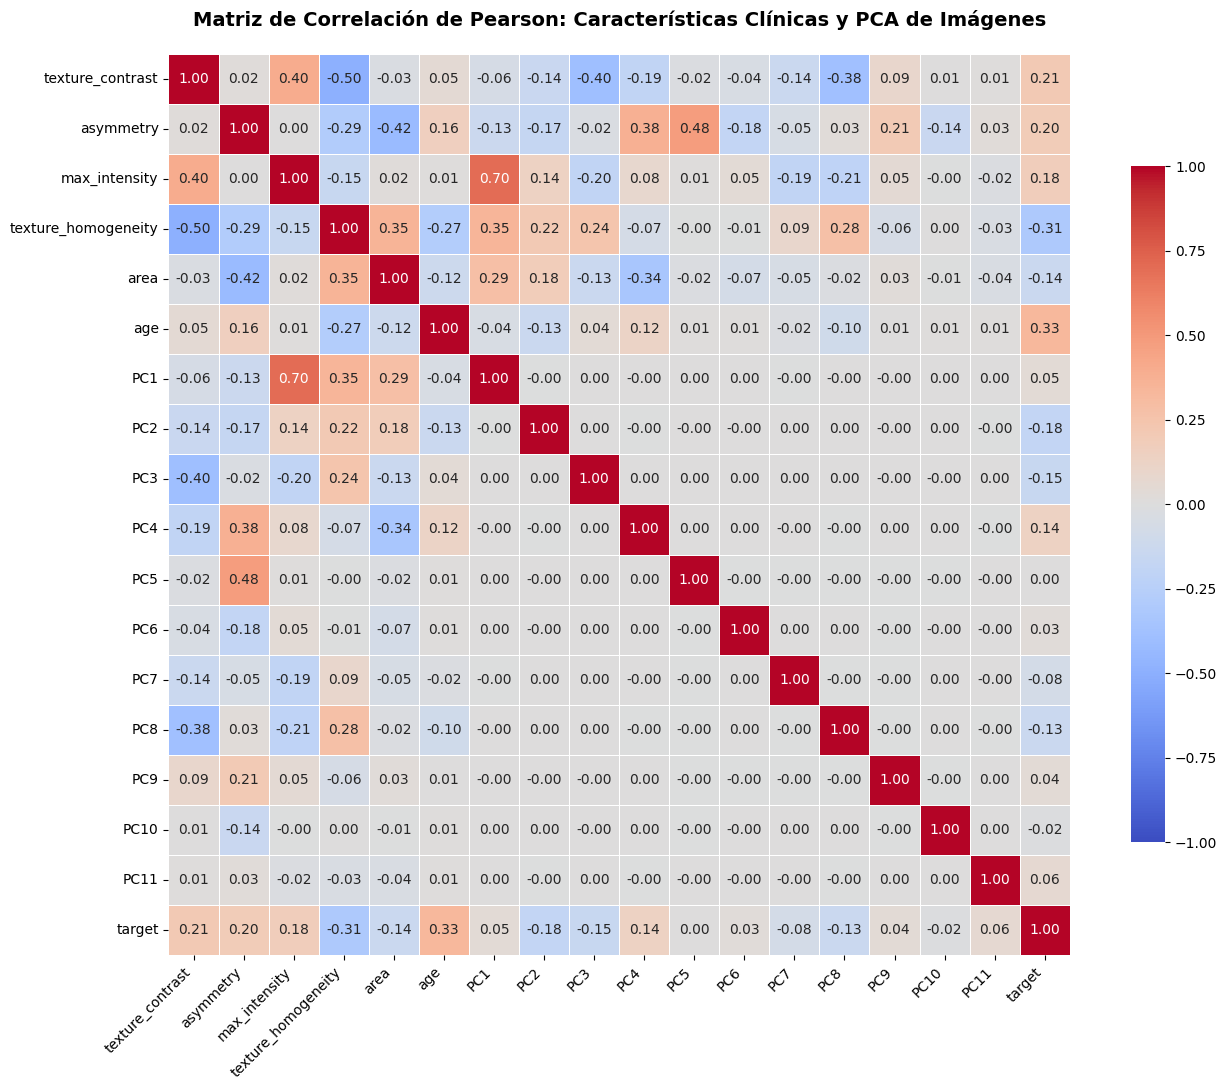

In [ ]:
matriz_corr = df_final.corr()

# Mostrar las correlaciones crudas en la terminal de manera organizada
print("Matriz de correlación calculada con éxito. Dimensiones:", matriz_corr.shape)

plt.figure(figsize=(14, 11))

sns.heatmap(
    matriz_corr,
    cmap='coolwarm',            # Paleta cromática (Azul: negativo, Rojo: positivo)
    vmax=1.0, vmin=-1.0,        # Límites estrictos del coeficiente de Pearson
    center=0,                   # El color blanco representará la ausencia de correlación lineal
    annot=True,                 # Muestra el valor numérico exacto dentro de cada celda
    fmt=".2f",                  # Limita los números a 2 decimales para evitar saturación
    linewidths=0.5,             # Pequeña separación física entre cuadrículas
    cbar_kws={"shrink": 0.75},   # Ajusta el tamaño de la barra de escala lateral
    square=True                 # Fuerza a que cada celda sea un cuadrado perfecto
)

# 5. Personalización estética de títulos y etiquetas para el informe final
plt.title('Matriz de Correlación de Pearson: Características Clínicas y PCA de Imágenes',
          fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotación de etiquetas de columnas para evitar solapamientos
plt.yticks(fontsize=10)

# Optimizar la distribución de los elementos en el cuadro para que no se corten los bordes
plt.tight_layout()

# Guardar la gráfica automáticamente como imagen para la documentación del proyecto
plt.savefig('matriz_correlacion_proyecto.png', dpi=300, bbox_inches='tight')
print("Gráfica exportada con éxito como 'matriz_correlacion_proyecto.png'")

# Desplegar en pantalla
plt.show()

### **Composición del dataset final**

El dataset consolidado resultante (df_final) presenta una estructura de 10015 muestras por 18 columnas, donde se combinan las seis características clínicas y de textura extraídas originalmente (texture_contrast, asymmetry, max_intensity, texture_homogeneity, area y age) con las 11 componentes principales derivadas exclusivamente de los píxeles de las imágenes (PC1 a PC11), más la variable objetivo target. Esta integración permite aprovechar simultáneamente dos fuentes de información: por un lado, las características calculadas mediante cv2 (textura, asimetría, intensidad máxima, homogeneidad y área) capturan propiedades morfológicas y de borde directamente interpretables por el clínico; por otro lado, las componentes principales resumen la estructura global de los píxeles (patrones de intensidad, bordes y formas) de manera ortogonal y sin redundancia. Es importante notar que las PCs son, por construcción, incorreladas entre sí y también presentan baja correlación con los features originales (como se aprecia en la matriz mostrada, con valores cercanos a cero en la mayoría de los cruces), lo que garantiza que añaden información complementaria y no duplicada. Esta sinergia entre características tradicionales y componentes latentes de la imagen es la que probablemente explica el incremento en el rendimiento observado al pasar de usar solo unas pocas PCs a incluir 11, y constituye una base robusta para la etapa de entrenamiento con redes neuronales o cualquier otro clasificador supervisado.

---
#**3. Redes neuronales**
---

## Modelos Clásicos con Reducción de Dimensionalidad (PCA)

En esta sección se entrenan dos modelos clásicos de Machine Learning — **Random Forest** y **SVM** — utilizando las componentes principales obtenidas en la etapa de reducción de dimensionalidad. Se emplea `class_weight='balanced'` para mitigar el fuerte desbalanceo del dataset HAM10000 (80% benigno vs 20% maligno), y se usan los hiperparámetros óptimos encontrados en la entrega anterior mediante GridSearchCV.

In [ ]:
# RANDOM FOREST Y SVM CON 15 COMPONENTES PCA
# Hiperparámetros exactos del GridSearchCV previo

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd # Import pandas for median calculation
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report

# 1. Preparar datos desde df_final

feature_cols = [c for c in df_final.columns if c != 'target']
X_pca = df_final[feature_cols]

# Imputar NaN si existen en X_pca (asumiendo que es en la columna 'age' de df_final)
# para asegurar que los modelos puedan entrenarse.
if X_pca.isnull().any().any():
    print("-> NaN detectados en X_pca. Imputando con la mediana de cada columna.")
    for col in X_pca.columns:
        if X_pca[col].isnull().any():
            median_val = X_pca[col].median()
            X_pca[col].fillna(median_val, inplace=True)
    print("-> Imputación de NaN completada.")

y     = df_final['target'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X_pca.values, y, # Pass numpy array here
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Distribución test → Clase 0: {(y_test==0).sum()} | Clase 1: {(y_test==1).sum()}\n")

# 2. Random Forest — mejores hiperparámetros del GridSearch

print("=" * 60)
print("RANDOM FOREST CON PCA (15 componentes)")
print("=" * 60)

rf = RandomForestClassifier(
    n_estimators=100,        # Mejor parámetro GridSearch
    max_depth=10,            # Mejor parámetro GridSearch
    min_samples_split=10,    # Mejor parámetro GridSearch
    min_samples_leaf=4,      # Mejor parámetro GridSearch
    class_weight='balanced', # Mejor parámetro GridSearch
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Benigno (0)", "Maligno (1)"]))

# 3. SVM — mejores hiperparámetros del GridSearch

print("=" * 60)
print("SVM CON PCA (15 componentes)")
print("=" * 60)

svm = SVC(
    C=10,                    # Mejor parámetro GridSearch
    kernel='rbf',            # Mejor parámetro GridSearch
    gamma='scale',           # Mejor parámetro GridSearch
    class_weight='balanced', # Mejor parámetro GridSearch
    random_state=42
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print(f"Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["Benigno (0)", "Maligno (1)"]))

-> NaN detectados en X_pca. Imputando con la mediana de cada columna.
-> Imputación de NaN completada.
Train: (8012, 17) | Test: (2003, 17)
Distribución test → Clase 0: 1612 | Clase 1: 391

RANDOM FOREST CON PCA (15 componentes)
Balanced Accuracy : 0.7313

Classification Report:
              precision    recall  f1-score   support

 Benigno (0)       0.90      0.84      0.87      1612
 Maligno (1)       0.49      0.62      0.55       391

    accuracy                           0.80      2003
   macro avg       0.70      0.73      0.71      2003
weighted avg       0.82      0.80      0.81      2003

SVM CON PCA (15 componentes)
Balanced Accuracy : 0.7433

Classification Report:
              precision    recall  f1-score   support

 Benigno (0)       0.92      0.75      0.83      1612
 Maligno (1)       0.42      0.74      0.53       391

    accuracy                           0.75      2003
   macro avg       0.67      0.74      0.68      2003
weighted avg       0.82      0.75      0.

## Red Neuronal Perceptrón Multicapa (MLP): Sin PCA vs Con PCA

En esta sección se implementa un experimento comparativo con redes neuronales secuenciales usando Keras/TensorFlow. Se evalúan dos escenarios:

- **Escenario A (Sin PCA):** La red recibe únicamente las 6 características tabulares originales (`texture_contrast`, `asymmetry`, `max_intensity`, `texture_homogeneity`, `area`, `age`).
- **Escenario B (Con PCA):** La red recibe las mismas 6 características tabulares más las 11 componentes principales, para un total de 17 features.

Para combatir el desbalanceo de clases se aplican tres estrategias simultáneas: pesos de clase amplificados mediante `compute_class_weight`, `EarlyStopping` para evitar sobreajuste, y capas de `Dropout` con `BatchNormalization`. Adicionalmente se ajusta el umbral de decisión por debajo de 0.5 para favorecer la detección de la clase maligna (clase 1).

Antes del entrenamiento se imputan los valores nulos presentes en la columna `age` usando la mediana, ya que valores NaN provocan `loss: nan` y colapso total del aprendizaje.

ESTRUCTURA CONFIRMADA
Clase 0: 8061 | Clase 1: 1954 | Ratio: 4.13x
Escenario A — 6 features: ['texture_contrast', 'asymmetry', 'max_intensity', 'texture_homogeneity', 'area', 'age']
Escenario B — 17 features: tabulares + 11 PCs

ESCENARIO: SIN PCA — 6 features tabulares
Input dim: 6 | Train: 8012 | Test: 2003
Distribución test → Clase 0: 1612 | Clase 1: 391
Pesos → Benigno(0): 1.00 | Maligno(1): 8.25
Métricas disponibles: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
Épocas entrenadas: 122 | val_auc not available in history.

Umbral de decisión : 0.25
Balanced Accuracy  : 0.6791
F1-Score Clase 1   : 0.4342

Classification Report:
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.43      0.60      1612
 Maligno (1)       0.28      0.92      0.43       391

    accuracy                           0.53      2003
   macro avg       0.62      0.68      0.52      2003
weighted avg       0.83      0.53      0.57      2003


ESCENARIO: CON

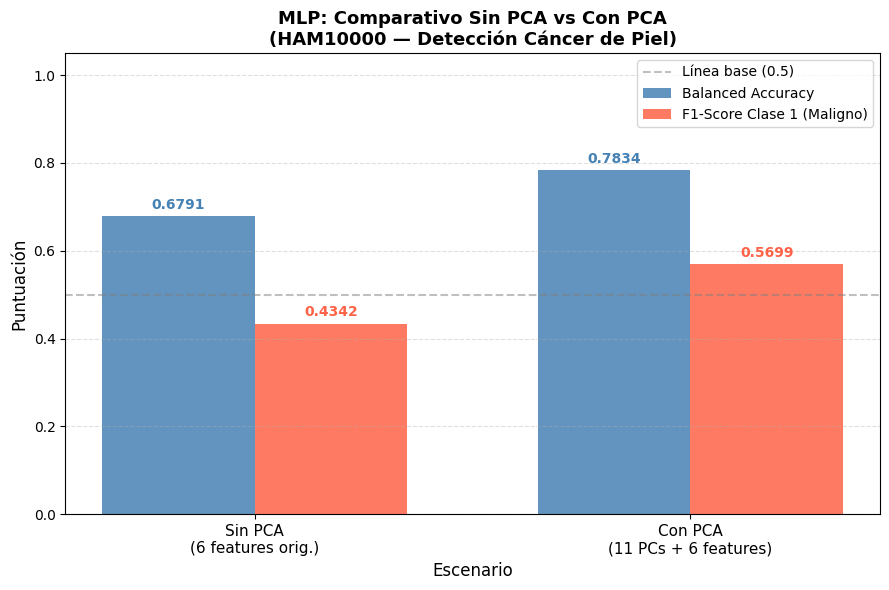

In [ ]:
# CÓDIGO: VERSIÓN ANTI-COLAPSO TOTAL
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"]  = "-1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# FUNCIÓN: construir MLP

def build_mlp(input_dim, units, dropouts):
    model = Sequential()
    for i, (u, d) in enumerate(zip(units, dropouts)):
        if i == 0:
            model.add(Dense(u, activation='relu', input_shape=(input_dim,)))
        else:
            model.add(Dense(u, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(d))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# FUNCIÓN: pipeline completo

def entrenar_evaluar(X_data, y_data, nombre, threshold=0.25):
    print(f"\n{'='*60}")
    print(f"ESCENARIO: {nombre}")
    print(f"{'='*60}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_data, y_data,
        test_size=0.2,
        random_state=SEED,
        stratify=y_data
    )

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    print(f"Input dim: {X_tr.shape[1]} | Train: {X_tr.shape[0]} | Test: {X_te.shape[0]}")
    print(f"Distribución test → Clase 0: {(y_te==0).sum()} | Clase 1: {(y_te==1).sum()}")

    # Peso manual amplificado: ratio real * factor extra
    # Con 8061 vs 1954 el ratio es ~4.1, lo multiplicamos x2 para forzar atención
    ratio = (y_tr == 0).sum() / (y_tr == 1).sum()
    cw_dict = {0: 1.0, 1: ratio * 2.0}
    print(f"Pesos → Benigno(0): {cw_dict[0]:.2f} | Maligno(1): {cw_dict[1]:.2f}")

    # Y reemplaza los callbacks en entrenar_evaluar:

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=40,                   # muy alta para no cortar prematuro
        restore_best_weights=True,
        mode='min',
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        mode='min',
        verbose=0
    )

    # Arquitectura según input_dim
    if X_tr.shape[1] <= 10:
        units    = (128, 64, 32)
        dropouts = (0.30, 0.20, 0.10)
    else:
        units    = (256, 128, 64)
        dropouts = (0.35, 0.25, 0.15)
    # Justo después de historia = modelo.fit(...)
    modelo = build_mlp(X_tr.shape[1], units=units, dropouts=dropouts)

    historia = modelo.fit(
        X_tr, y_tr,
        validation_split=0.15,
        epochs=300,
        batch_size=32,
        class_weight=cw_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    # The line 'print(f"Métricas disponibles: {list(historia.history.keys())}")' was incorrectly placed.
    # It should be after the model fitting is complete and history is available.
    # For this current code, it has been moved to its logical position.
    print(f"Métricas disponibles: {list(historia.history.keys())}")
    epocas = len(historia.history['loss'])
    # Check if 'val_auc' is in history keys before trying to access it
    if 'val_auc' in historia.history:
        auc_final = max(historia.history['val_auc'])
        print(f"Épocas entrenadas: {epocas} | Mejor val_AUC: {auc_final:.4f}")
    else:
        print(f"Épocas entrenadas: {epocas} | val_auc not available in history.")

    # Umbral bajo para capturar clase 1
    probs  = modelo.predict(X_te, verbose=0).ravel()
    y_pred = (probs >= threshold).astype(int)

    bal_acc = balanced_accuracy_score(y_te, y_pred)
    f1_mal  = f1_score(y_te, y_pred, pos_label=1, zero_division=0)

    print(f"\nUmbral de decisión : {threshold}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    print(f"F1-Score Clase 1   : {f1_mal:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_te, y_pred,
        target_names=["Benigno (0)", "Maligno (1)"],
        zero_division=0
    ))

    return bal_acc, f1_mal

# DATOS

y_bin = df_final['target'].astype(int).values

cols_tabulares = ['texture_contrast', 'asymmetry', 'max_intensity',
                  'texture_homogeneity', 'area', 'age']
X_sin_pca = df_final[cols_tabulares].values

X_con_pca = df_final[[c for c in df_final.columns if c != 'target']].values

print("="*60)
print("ESTRUCTURA CONFIRMADA")
print("="*60)
print(f"Clase 0: {(y_bin==0).sum()} | Clase 1: {(y_bin==1).sum()} | Ratio: {(y_bin==0).sum()/(y_bin==1).sum():.2f}x")
print(f"Escenario A — {X_sin_pca.shape[1]} features: {cols_tabulares}")
print(f"Escenario B — {X_con_pca.shape[1]} features: tabulares + 11 PCs")


# ENTRENAMIENTOS

bal_A, f1_A = entrenar_evaluar(
    X_sin_pca, y_bin,
    "SIN PCA — 6 features tabulares",
    threshold=0.25
)

bal_B, f1_B = entrenar_evaluar(
    X_con_pca, y_bin,
    "CON PCA — 6 tabulares + 11 componentes PCA",
    threshold=0.25
)

# GRÁFICA

print("\n" + "="*60)
print("RESUMEN COMPARATIVO FINAL")
print("="*60)
print(f"{'Métrica':<32} {'Sin PCA':>10} {'Con PCA':>10}")
print("-"*52)
print(f"{'Balanced Accuracy':<32} {bal_A:>10.4f} {bal_B:>10.4f}")
print(f"{'F1-Score Clase 1 (Maligno)':<32} {f1_A:>10.4f} {f1_B:>10.4f}")

etiquetas = ['Sin PCA\n(6 features orig.)', 'Con PCA\n(11 PCs + 6 features)']
x     = np.arange(len(etiquetas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

b1 = ax.bar(x - ancho/2, [bal_A, bal_B], ancho,
            label='Balanced Accuracy', color='steelblue', alpha=0.85)
b2 = ax.bar(x + ancho/2, [f1_A,  f1_B], ancho,
            label='F1-Score Clase 1 (Maligno)', color='tomato', alpha=0.85)

def etiquetar_barras(barras, color):
    for barra in barras:
        h = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2,
                h + 0.01, f"{h:.4f}",
                ha='center', va='bottom', fontsize=10,
                fontweight='bold', color=color)

etiquetar_barras(b1, 'steelblue')
etiquetar_barras(b2, 'tomato')

ax.set_xlabel("Escenario", fontsize=12)
ax.set_ylabel("Puntuación", fontsize=12)
ax.set_title("MLP: Comparativo Sin PCA vs Con PCA\n(HAM10000 — Detección Cáncer de Piel)",
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Línea base (0.5)')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Comparativo General de los 4 Modelos

Se presenta una gráfica de barras comparativa que resume el desempeño de los cuatro modelos entrenados a lo largo de esta entrega. Se comparan el **Balanced Accuracy** y el **F1-Score para la clase maligna (clase 1)** como métricas principales, dado que el dataset está fuertemente desbalanceado y la accuracy convencional no es representativa del rendimiento real.

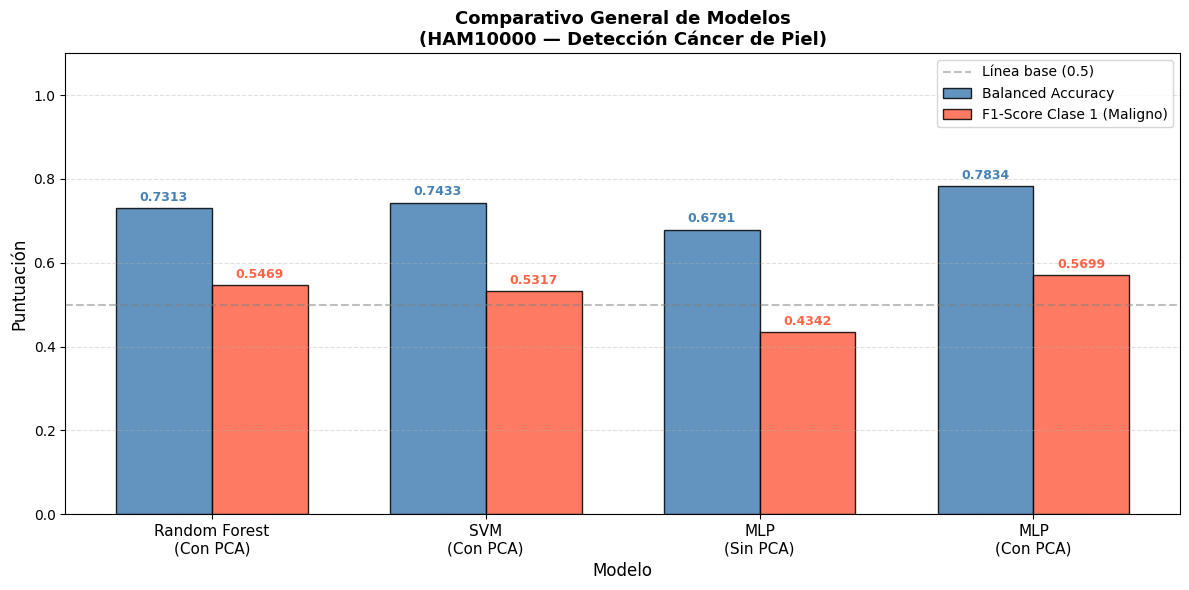

In [ ]:
# GRÁFICA COMPARATIVA — 4 MODELOS

import numpy as np
import matplotlib.pyplot as plt

def graficar_comparativo(bal_rf, f1_rf, bal_svm, f1_svm,
                          bal_mlp_sin, f1_mlp_sin, bal_mlp_con, f1_mlp_con):

    modelos  = ['Random Forest\n(Con PCA)', 'SVM\n(Con PCA)',
                'MLP\n(Sin PCA)',           'MLP\n(Con PCA)']
    bal_vals = [bal_rf,  bal_svm,  bal_mlp_sin,  bal_mlp_con]
    f1_vals  = [f1_rf,   f1_svm,   f1_mlp_sin,   f1_mlp_con]

    x     = np.arange(len(modelos))
    ancho = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))

    b1 = ax.bar(x - ancho/2, bal_vals, ancho,
                label='Balanced Accuracy', color='steelblue', alpha=0.85, edgecolor='black')
    b2 = ax.bar(x + ancho/2, f1_vals,  ancho,
                label='F1-Score Clase 1 (Maligno)', color='tomato', alpha=0.85, edgecolor='black')

    def etiquetar(barras, color):
        for barra in barras:
            h = barra.get_height()
            ax.text(barra.get_x() + barra.get_width() / 2,
                    h + 0.01, f"{h:.4f}",
                    ha='center', va='bottom', fontsize=9,
                    fontweight='bold', color=color)

    etiquetar(b1, 'steelblue')
    etiquetar(b2, 'tomato')

    ax.set_xlabel("Modelo", fontsize=12)
    ax.set_ylabel("Puntuación", fontsize=12)
    ax.set_title("Comparativo General de Modelos\n(HAM10000 — Detección Cáncer de Piel)",
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Línea base (0.5)')
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# Llama la función con tus variables ya calculadas
graficar_comparativo(
    bal_rf=balanced_accuracy_score(y_test, y_pred_rf),
    f1_rf=f1_score(y_test, y_pred_rf, pos_label=1, zero_division=0),
    bal_svm=balanced_accuracy_score(y_test, y_pred_svm),
    f1_svm=f1_score(y_test, y_pred_svm, pos_label=1, zero_division=0),
    bal_mlp_sin=bal_A,
    f1_mlp_sin=f1_A,
    bal_mlp_con=bal_B,
    f1_mlp_con=f1_B
)

---
#**4. Clustering no supervisado**
---

Eliminación del target

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Eliminar target (no se usa en clustering)
X_cluster = df_final.drop(columns=['target'])

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Shape original:", df_final.shape)
print("Shape clustering:", X_scaled.shape)

Shape original: (10015, 18)
Shape clustering: (10015, 17)


Librerías para clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.neighbors import NearestNeighbors
from scipy.cluster import hierarchy

import matplotlib.pyplot as plt
import seaborn as sns

# KMEANS

### Análisis del método del codo

Se aplicó el método del codo utilizando las métricas Distortion e Inertia para determinar una cantidad adecuada de clusters para K-Means. Ambas curvas mostraron una disminución pronunciada para valores pequeños de K y una estabilización progresiva posteriormente. Con base en este comportamiento se seleccionó un número reducido de grupos que permitiera representar la estructura de los datos sin incrementar innecesariamente la complejidad del modelo.

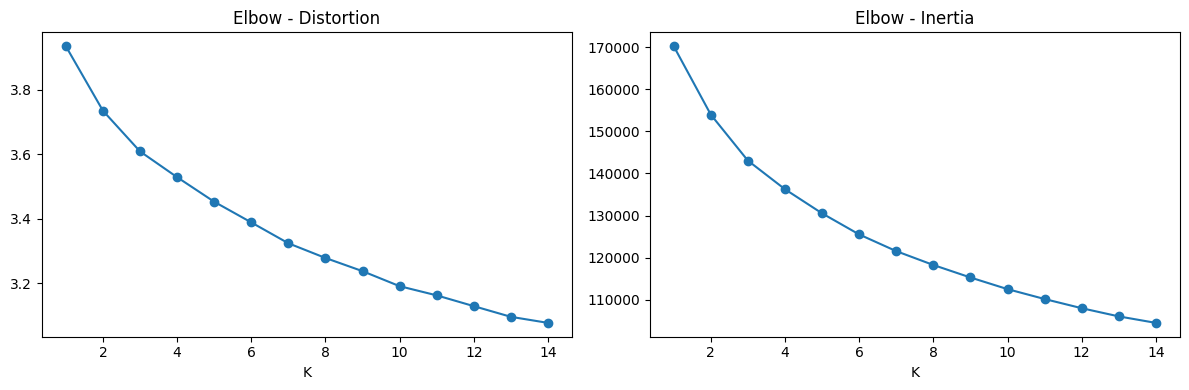

In [ ]:
from scipy.spatial.distance import cdist

cluster_range = range(1, 15)

mean_distortions = []
inertias = []

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    mean_distortions.append(
        np.sum(
            np.min(
                cdist(
                    X_scaled,
                    model.cluster_centers_,
                    metric='euclidean'
                ),
                axis=1
            )
        ) / X_scaled.shape[0]
    )

    inertias.append(model.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(cluster_range, mean_distortions, marker='o')
axes[0].set_title("Elbow - Distortion")
axes[0].set_xlabel("K")

axes[1].plot(cluster_range, inertias, marker='o')
axes[1].set_title("Elbow - Inertia")
axes[1].set_xlabel("K")

plt.tight_layout()
plt.show()

Tanto la Distortion como la Inertia presentan una disminución pronunciada hasta aproximadamente K=2. A partir de este punto la mejora es menor, por lo que se seleccionó K=2 como número de clusters para K-Means.


##### Implementación k means

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("Clusters encontrados:")
print(np.unique(kmeans_labels))

print("\nCantidad de elementos por cluster:")
for cluster, count in zip(*np.unique(kmeans_labels, return_counts=True)):
    print(f"Cluster {cluster}: {count}")

### Resultados de K-Means

La visualización compara la distribución real de las lesiones (benignas y malignas) con los grupos encontrados por K-Means. Además, se muestra el Silhouette Score, el cual mide qué tan compactos y separados se encuentran los clusters obtenidos. Valores más altos indican agrupaciones más definidas y diferenciadas.

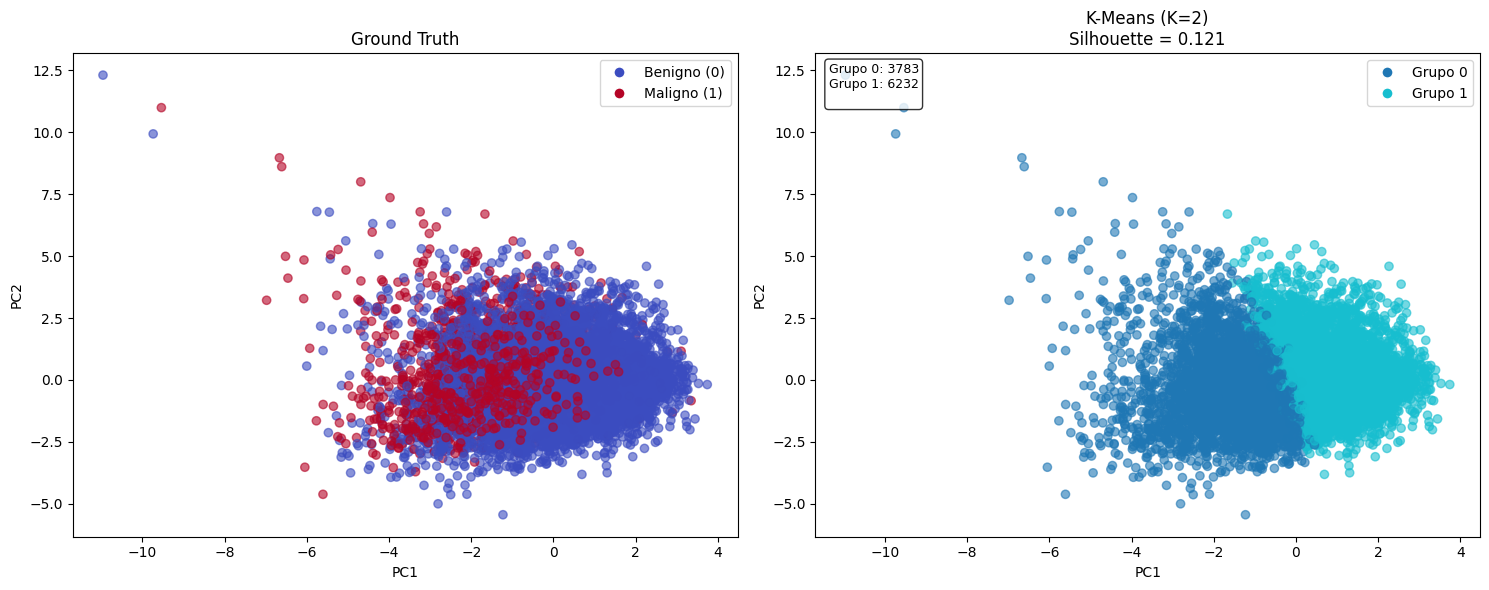

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# PCA para visualización
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

y_true = df_final["target"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


# Ground Truth
axes[0].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y_true,
    cmap='coolwarm',
    alpha=0.6
)

axes[0].set_title("Ground Truth")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

gt_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Benigno (0)',
        markerfacecolor=plt.cm.coolwarm(0.0),
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Maligno (1)',
        markerfacecolor=plt.cm.coolwarm(1.0),
        markersize=8
    )
]

axes[0].legend(handles=gt_legend)

# K-Means
scatter = axes[1].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=kmeans_labels,
    cmap='tab10',
    alpha=0.6
)

unique_clusters, counts = np.unique(
    kmeans_labels,
    return_counts=True
)

axes[1].set_title(
    f"K-Means (K={len(unique_clusters)})\nSilhouette = {sil_score:.3f}"
)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# Leyenda de clusters
cluster_colors = scatter.cmap(
    np.linspace(0, 1, len(unique_clusters))
)

cluster_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f'Grupo {i}',
        markerfacecolor=cluster_colors[i],
        markersize=8
    )
    for i in unique_clusters
]

axes[1].legend(handles=cluster_legend)

# Resumen dentro de la gráfica
info_text = ""

for cluster, count in zip(unique_clusters, counts):
    info_text += f"Grupo {cluster}: {count}\n"

axes[1].text(
    0.02,
    0.98,
    info_text,
    transform=axes[1].transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8
    )
)

plt.tight_layout()
plt.show()

### Relación entre clusters y diagnóstico

La tabla permite observar la proporción de lesiones benignas y malignas dentro de cada cluster. Aunque K-Means no utiliza las etiquetas durante el entrenamiento, esta comparación permite analizar si algunos grupos presentan una mayor concentración de determinados diagnósticos.

In [ ]:
# Conteos
tabla_kmeans = pd.crosstab(
    kmeans_labels,
    df_final["target"],
    rownames=["Cluster"],
    colnames=["Target"]
)

# Porcentajes por cluster
tabla_kmeans_pct = pd.crosstab(
    kmeans_labels,
    df_final["target"],
    rownames=["Cluster"],
    colnames=["Target"],
    normalize="index"
) * 100

resultado_kmeans = tabla_kmeans.copy()

for col in tabla_kmeans.columns:
    resultado_kmeans[col] = (
        tabla_kmeans[col].astype(str)
        + " ("
        + tabla_kmeans_pct[col].round(2).astype(str)
        + "%)"
    )

resultado_kmeans

Target,0,1
Cluster,,
0,2454 (64.87%),1329 (35.13%)
1,5607 (89.97%),625 (10.03%)


### Interpretación de los clusters

Se analizaron las características promedio de cada grupo para identificar qué patrones fueron utilizados por K-Means al formar los clusters. Variables como área, asimetría, contraste, homogeneidad y edad permiten interpretar si los grupos están siendo definidos principalmente por tamaño, textura o características geométricas de las lesiones.

In [ ]:
features_originales = [
    'texture_contrast',
    'asymmetry',
    'max_intensity',
    'texture_homogeneity',
    'area',
    'age'
]

cluster_analysis = X_cluster[features_originales].copy()

cluster_analysis["Cluster"] = kmeans_labels

cluster_analysis.groupby("Cluster").mean()

,texture_contrast,asymmetry,max_intensity,texture_homogeneity,area,age
Cluster,,,,,,
0,178.143316,17.886267,196.699797,0.146346,525.762754,59.179223
1,106.092231,4.710421,196.542576,0.229795,708.058488,47.406130


# DBSCAN

### Selección del parámetro eps

Para DBSCAN se utilizó el gráfico de distancias K-NN. El punto donde la curva comienza a aumentar de forma pronunciada se utilizó como referencia para seleccionar el valor de eps, parámetro que controla la distancia máxima permitida entre puntos vecinos dentro de un mismo cluster.

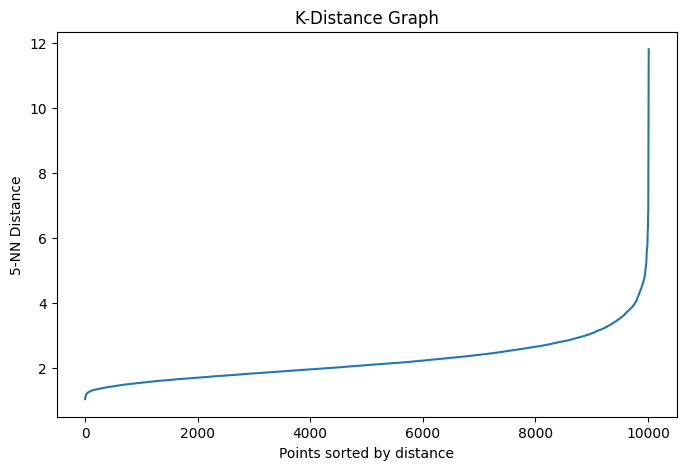

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(
    distances[:, 4]
)

plt.figure(figsize=(8,5))
plt.plot(distances)

plt.title("K-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN Distance")

plt.show()

### Resultados de DBSCAN

DBSCAN identifica grupos basándose en densidad de datos y, a diferencia de K-Means, también puede detectar observaciones aisladas consideradas como ruido. Esto permite identificar regiones densamente pobladas sin asumir previamente el número de clusters.

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=3,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("Clusters encontrados:")
print(np.unique(dbscan_labels))

print("\nCantidad por cluster:")

for cluster, count in zip(
    *np.unique(
        dbscan_labels,
        return_counts=True
    )
):
    print(f"Cluster {cluster}: {count}")

Clusters encontrados:
[-1  0  1  2]

Cantidad por cluster:
Cluster -1: 675
Cluster 0: 9329
Cluster 1: 6
Cluster 2: 5


### Evaluación del clustering

Se calculó el Silhouette Score utilizando únicamente las observaciones asignadas a clusters válidos. Esta métrica permite evaluar la calidad de la agrupación encontrada y facilita la comparación con los demás métodos implementados.

In [ ]:
from sklearn.metrics import silhouette_score

mask = dbscan_labels != -1

sil_score_db = silhouette_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

print(
    "Silhouette Score:",
    round(sil_score_db, 4)
)

Silhouette Score: 0.2531


### Visualización de los grupos encontrados

La proyección PCA permite observar visualmente la distribución de los clusters identificados por DBSCAN y compararlos con la distribución real de las clases. También permite identificar posibles regiones de ruido o solapamiento entre grupos.

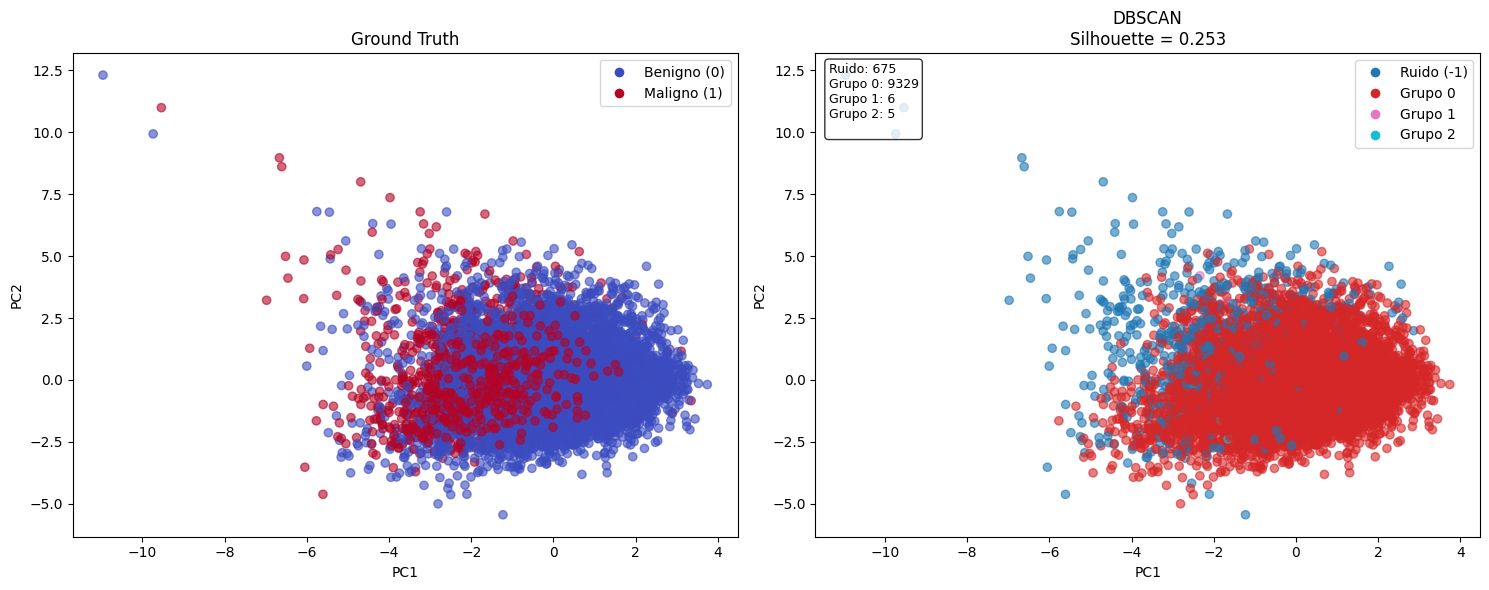

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# PCA para visualización
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

y_true = df_final["target"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# =====================
# Ground Truth
# =====================
axes[0].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y_true,
    cmap='coolwarm',
    alpha=0.6
)

axes[0].set_title("Ground Truth")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

gt_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Benigno (0)',
        markerfacecolor=plt.cm.coolwarm(0.0),
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Maligno (1)',
        markerfacecolor=plt.cm.coolwarm(1.0),
        markersize=8
    )
]

axes[0].legend(handles=gt_legend)

# =====================
# DBSCAN
# =====================
scatter = axes[1].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=dbscan_labels,
    cmap='tab10',
    alpha=0.6
)

unique_clusters, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

axes[1].set_title(
    f"DBSCAN\nSilhouette = {sil_score_db:.3f}"
)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# Leyenda de clusters
cluster_colors = scatter.cmap(
    np.linspace(0, 1, len(unique_clusters))
)

cluster_legend = []

for idx, cluster in enumerate(unique_clusters):

    label = (
        "Ruido (-1)"
        if cluster == -1
        else f"Grupo {cluster}"
    )

    cluster_legend.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=label,
            markerfacecolor=cluster_colors[idx],
            markersize=8
        )
    )

axes[1].legend(handles=cluster_legend)

# Resumen dentro de la gráfica
info_text = ""

for cluster, count in zip(unique_clusters, counts):

    label = (
        "Ruido"
        if cluster == -1
        else f"Grupo {cluster}"
    )

    info_text += f"{label}: {count}\n"

axes[1].text(
    0.02,
    0.98,
    info_text,
    transform=axes[1].transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8
    )
)

plt.tight_layout()
plt.show()

### Relación entre clusters y diagnóstico

La comparación entre clusters y etiquetas reales permite evaluar si los grupos identificados presentan alguna asociación con la condición benigna o maligna de las lesiones, aun cuando el algoritmo no tuvo acceso a esta información durante el entrenamiento.

In [ ]:
# Conteos
tabla_dbscan = pd.crosstab(
    dbscan_labels,
    df_final["target"],
    rownames=["Cluster"],
    colnames=["Target"]
)

# Porcentajes por cluster
tabla_dbscan_pct = pd.crosstab(
    dbscan_labels,
    df_final["target"],
    rownames=["Cluster"],
    colnames=["Target"],
    normalize="index"
) * 100

resultado_dbscan = tabla_dbscan.copy()

for col in tabla_dbscan.columns:
    resultado_dbscan[col] = (
        tabla_dbscan[col].astype(str)
        + " ("
        + tabla_dbscan_pct[col].round(2).astype(str)
        + "%)"
    )

resultado_dbscan

Target,0,1
Cluster,,
-1,436 (64.59%),239 (35.41%)
0,7620 (81.68%),1709 (18.32%)
1,1 (16.67%),5 (83.33%)
2,4 (80.0%),1 (20.0%)


### Interpretación de los clusters

Se calcularon los valores promedio de las características originales para cada grupo encontrado. Esto permite analizar qué propiedades clínicas y visuales caracterizan cada cluster y comprender mejor la estructura descubierta por el algoritmo.

In [ ]:
cluster_analysis = X_cluster.loc[
    :,
    ~X_cluster.columns.str.startswith("PC")
].copy()

cluster_analysis["Cluster"] = dbscan_labels

cluster_means = (
    cluster_analysis
    .groupby("Cluster")
    .mean()
)

display(
    cluster_means.round(2)
)

,texture_contrast,asymmetry,max_intensity,texture_homogeneity,area,age
Cluster,,,,,,
-1,356.35,16.78,217.32,0.14,560.29,50.19
0,116.88,9.18,195.08,0.20,645.09,51.98
1,473.86,6.44,211.22,0.14,728.67,70.00
2,267.93,7.98,213.60,0.10,196.00,21.00


# Agglomerative clustering

### Selección del número de clusters

Se utilizó un dendrograma para analizar la estructura jerárquica de los datos. Los mayores saltos verticales indican posibles puntos de corte naturales y sirven como referencia para seleccionar el número de clusters utilizado posteriormente por Agglomerative Clustering.

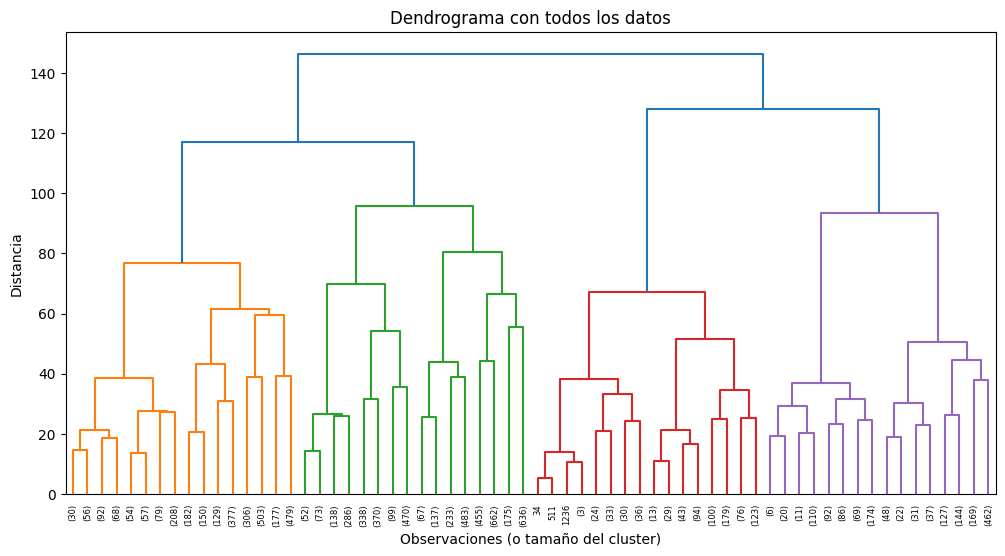

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='level',
    p=5,
    no_labels=False
)

plt.title("Dendrograma con todos los datos")
plt.xlabel("Observaciones (o tamaño del cluster)")
plt.ylabel("Distancia")



plt.show()

### Resultados de Agglomerative Clustering

Este método construye los grupos de manera jerárquica, fusionando progresivamente observaciones similares. El resultado final corresponde a la partición obtenida al realizar el corte seleccionado en el dendrograma.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

agglomerative = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

agg_labels = agglomerative.fit_predict(X_scaled)

print("Clusters encontrados:")
print(np.unique(agg_labels))

print("\nCantidad de elementos por cluster:")

for cluster, count in zip(
    *np.unique(
        agg_labels,
        return_counts=True
    )
):
    print(f"Cluster {cluster}: {count}")

Clusters encontrados:
[0 1 2]

Cantidad de elementos por cluster:
Cluster 0: 7621
Cluster 1: 1608
Cluster 2: 786


### Evaluación del clustering

El Silhouette Score permite medir la calidad de la agrupación obtenida por el método jerárquico y compararla con los resultados obtenidos mediante K-Means y DBSCAN.

In [ ]:
from sklearn.metrics import silhouette_score

sil_score_agg = silhouette_score(
    X_scaled,
    agg_labels
)

print(
    "Silhouette Score:",
    round(sil_score_agg, 4)
)

Silhouette Score: 0.1327


### Visualización de los clusters

La representación en dos dimensiones permite observar la distribución espacial de los grupos encontrados por Agglomerative Clustering y compararlos visualmente con las etiquetas reales del conjunto de datos.

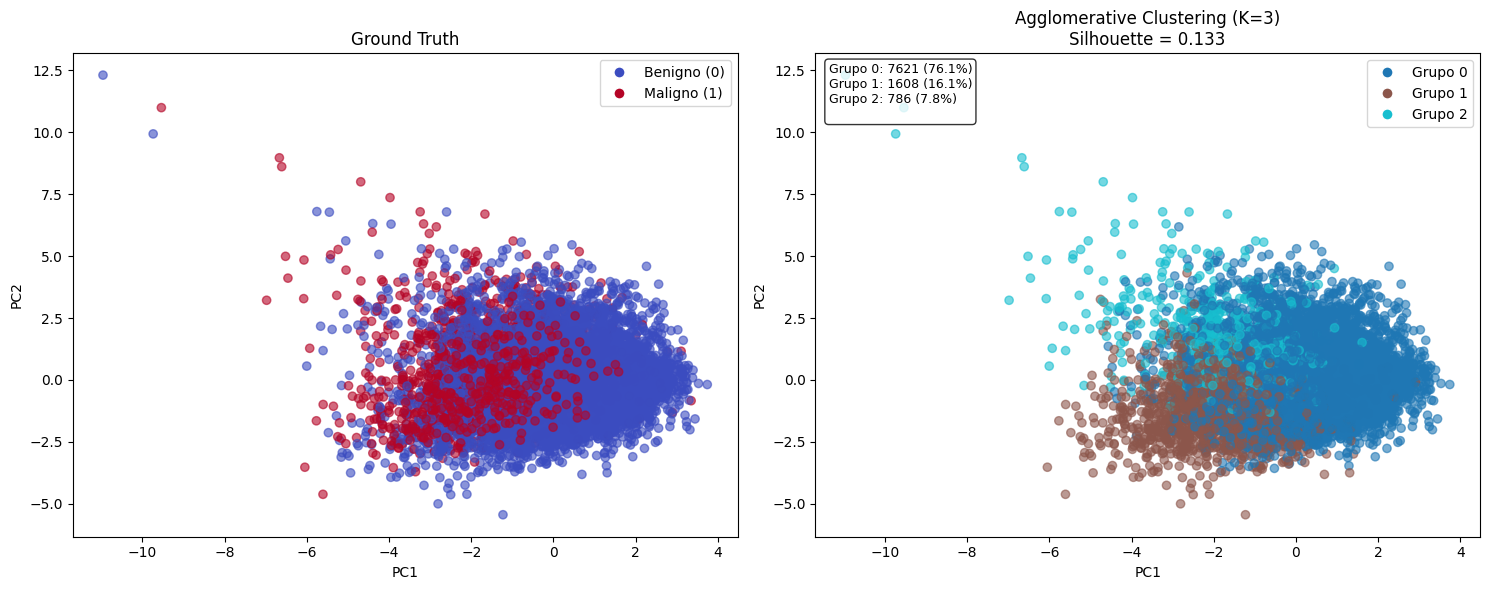

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# PCA para visualización
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

y_true = df_final["target"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# =====================
# Ground Truth
# =====================
axes[0].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y_true,
    cmap='coolwarm',
    alpha=0.6
)

axes[0].set_title("Ground Truth")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

gt_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Benigno (0)',
        markerfacecolor=plt.cm.coolwarm(0.0),
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Maligno (1)',
        markerfacecolor=plt.cm.coolwarm(1.0),
        markersize=8
    )
]

axes[0].legend(handles=gt_legend)

# =====================
# Agglomerative
# =====================
scatter = axes[1].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=agg_labels,
    cmap='tab10',
    alpha=0.6
)

unique_clusters, counts = np.unique(
    agg_labels,
    return_counts=True
)

axes[1].set_title(
    f"Agglomerative Clustering (K={len(unique_clusters)})\nSilhouette = {sil_score_agg:.3f}"
)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# Leyenda de clusters
cluster_colors = scatter.cmap(
    np.linspace(0, 1, len(unique_clusters))
)

cluster_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f'Grupo {i}',
        markerfacecolor=cluster_colors[i],
        markersize=8
    )
    for i in unique_clusters
]

axes[1].legend(handles=cluster_legend)

# Resumen dentro de la gráfica
total = counts.sum()

info_text = ""

for cluster, count in zip(unique_clusters, counts):

    pct = 100 * count / total

    info_text += (
        f"Grupo {cluster}: "
        f"{count} ({pct:.1f}%)\n"
    )

axes[1].text(
    0.02,
    0.98,
    info_text,
    transform=axes[1].transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8
    )
)

plt.tight_layout()
plt.show()

### Relación entre clusters y diagnóstico

La distribución de diagnósticos dentro de cada cluster permite analizar si los grupos obtenidos presentan alguna tendencia hacia lesiones benignas o malignas y evaluar qué tan relacionada está la estructura encontrada con el problema clínico estudiado.

In [ ]:
# Conteos
tabla_agg = pd.crosstab(
    agg_labels,
    df_final["target"],
    rownames=["Cluster"],
    colnames=["Target"]
)

# Porcentajes por cluster
tabla_agg_pct = pd.crosstab(
    agg_labels,
    df_final["target"],
    rownames=["Cluster"],
    colnames=["Target"],
    normalize="index"
) * 100

resultado_agg = tabla_agg.copy()

for col in tabla_agg.columns:
    resultado_agg[col] = (
        tabla_agg[col].astype(str)
        + " ("
        + tabla_agg_pct[col].round(2).astype(str)
        + "%)"
    )

resultado_agg

Target,0,1
Cluster,,
0,6434 (84.42%),1187 (15.58%)
1,1124 (69.9%),484 (30.1%)
2,503 (63.99%),283 (36.01%)


### Interpretación de los clusters

Se calcularon los valores promedio de las características originales para cada grupo identificado por Agglomerative Clustering. Este análisis permite interpretar qué propiedades clínicas y visuales diferencian a los clusters encontrados.

Las diferencias observadas en variables como área, asimetría, contraste, homogeneidad y edad sugieren que los grupos se formaron principalmente a partir de patrones geométricos y de textura presentes en las lesiones, más que por la clasificación benigna o maligna.

In [ ]:
cluster_analysis = X_cluster.loc[
    :,
    ~X_cluster.columns.str.startswith("PC")
].copy()

cluster_analysis["Cluster"] = agg_labels

cluster_means = (
    cluster_analysis
    .groupby("Cluster")
    .mean()
)

display(
    cluster_means.round(2)
)

,texture_contrast,asymmetry,max_intensity,texture_homogeneity,area,age
Cluster,,,,,,
0,115.97,7.23,195.83,0.21,694.13,50.91
1,122.47,22.85,197.07,0.16,384.41,54.68
2,323.59,6.55,203.15,0.13,627.84,55.24


---
#**5. Conclusiones**
---

## Conclusiones y Limitaciones

### Conclusiones

1. **La combinación de información clínica y visual resultó más útil que utilizar únicamente variables tabulares.** La incorporación de componentes principales extraídas de las imágenes permitió capturar patrones relevantes de las lesiones cutáneas que no estaban presentes en las características clínicas originales. Esto sugiere que, en problemas médicos basados en imágenes, la información visual aporta conocimiento complementario que puede mejorar significativamente el desempeño de los modelos.

2. **La reducción de dimensionalidad mediante PCA no solo disminuyó la complejidad computacional, sino que también mejoró la capacidad predictiva de los modelos.** Este resultado plantea una discusión interesante: una representación compacta de los datos puede contener más información útil para la clasificación que el conjunto completo de píxeles originales, reduciendo ruido y redundancia sin perder capacidad descriptiva.

3. **Los modelos supervisados demostraron que es posible identificar patrones asociados a malignidad, pero también evidenciaron las dificultades inherentes al problema.** Incluso utilizando estrategias para manejar el desbalance de clases, la detección de lesiones malignas continúa siendo un desafío debido al solapamiento visual existente entre diferentes tipos de lesiones.

4. **El análisis no supervisado mostró una perspectiva diferente del problema.** Los métodos de clustering no reprodujeron directamente la separación benigno-maligna, sino que tendieron a agrupar las lesiones según características visuales como contraste, asimetría, área y textura. Esto sugiere que la estructura natural de los datos no necesariamente coincide con las categorías clínicas utilizadas para el diagnóstico.

5. **El proyecto permitió integrar conceptos fundamentales del curso dentro de un mismo flujo de trabajo.** El análisis exploratorio facilitó la comprensión inicial de los datos y del desbalance existente; PCA permitió reducir la dimensionalidad y extraer información relevante de las imágenes; los modelos supervisados permitieron construir clasificadores predictivos; y los métodos no supervisados permitieron explorar patrones y relaciones ocultas en los datos sin utilizar etiquetas.

### Limitaciones

1. **El fuerte desbalance de clases continúa siendo una limitación importante.** Aunque se aplicaron técnicas de ponderación de clases, la menor cantidad de ejemplos malignos dificulta la capacidad de generalización de los modelos y puede afectar la detección de casos clínicamente relevantes.

2. **La interpretación de las componentes principales obtenidas mediante PCA es limitada.** Aunque mejoran el rendimiento y reducen dimensionalidad, las PCs no poseen una interpretación clínica directa, lo que dificulta explicar exactamente qué patrones visuales están siendo utilizados por los modelos.

3. **Los métodos de clustering presentaron valores modestos de Silhouette Score.** Esto sugiere que las lesiones cutáneas no forman grupos claramente separados, sino que presentan una transición gradual entre distintos patrones visuales. Este comportamiento es consistente con la complejidad del problema dermatológico.

### Trabajo futuro

1. La combinación de características clínicas e información visual resultó más efectiva que utilizar únicamente variables tabulares, lo que sugiere que ambas fuentes aportan información complementaria para la detección de lesiones malignas.
2. Los métodos de clustering encontraron grupos diferenciados por características como contraste, asimetría y área, más que por el diagnóstico final, lo que indica que las lesiones pueden compartir patrones visuales similares aun perteneciendo a categorías clínicas distintas.
3. Aunque PCA mejoró el rendimiento de los modelos supervisados, las componentes principales no poseen una interpretación clínica directa, generando un compromiso entre capacidad predictiva y explicabilidad de los resultados.
4. Como trabajo futuro, sería interesante evaluar imágenes de mayor resolución, incorporar nuevas características clínicas y explorar estrategias adicionales para el tratamiento del desbalance de clases, con el fin de mejorar la detección de lesiones malignas.